# System setup

In [1]:
# # download labtools from https://github.com/staller-lab/labtools
# # pip install :
# !pip install /global/home/users/empchase/packages/labtools 

In [3]:
# import sys
# sys.path.append('/global/home/users/empchase/packages/labtools' +'/src')
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from labtools.adtools.sort import Sort
from labtools.adtools.counter import seq_counter
from labtools.adtools.finder import pull_AD
from labtools.adtools.seqlib import get_numreads
from labtools.adtools.counter import create_map, convert_bcs_from_map
from labtools.adtools.seqlib import write_bc_dict
from matplotlib import lines as mlines
import matplotlib
import numpy as np
from Bio.Seq import Seq 

In [4]:
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

# Create new barcode map April 2, 2025
- get barcodes out of lib1
- concatenate to lib1 ('sog1_lib2_barcode_map_EC.csv')

## Create lib1 bc map (no need to re-run)

In [3]:
designfile = 'sog1_lib1/Sog1_lib1_design.txt' #copied from Sog1
files_to_analyze = [
    'sog1_lib1/LC_M1_checkstep1_rep1.fastq',
    'sog1_lib1/LC_M1_checkstep1_rep2.fastq',
]

In [4]:
barcodes, *otherthings = seq_counter(files_to_analyze, design_to_use=designfile, barcoded = True, bc_anteceder = "GGCGCGCC")

Opening file LC_M1_checkstep1_rep1.fastq ...
Total parsed reads = 1,443,210                      
Opening file LC_M1_checkstep1_rep2.fastq ...
Total parsed reads = 1,014,344                      


In [5]:
bc_map_stuff = create_map(barcodes)
bc_map=bc_map_stuff[0]

In [6]:
write_bc_dict(bc_map, 'sog1_lib1/sog1_lib1_barcode_map_EC20250402.csv')

## Combine the two bc maps

In [13]:
EC_folderpath = "../../../EChase/sog1/EC_analysis/"

In [14]:
lib2mapfpath = EC_folderpath + 'sog1_lib2_barcode_map_EC.csv'
lib2map = pd.read_csv(lib2mapfpath).T
lib2map = lib2map.reset_index()
lib2map.tail()

,index,0
500756,ACAGCACTAGA,CAACAACCACAACAATTGGTTGTTAAGAGAGGTGATAAAGCTGAAC...
500757,CAAGCGCAACA,GAAGATCCAACTTGGTTTGATTCTGCTGCTGCTGCTATCTTAAATT...
500758,CAATGTAGTTC,AAATGTCAACATGTTATTGATAATTCTGCTGTTGTTGCTGCTTGGC...
500759,CAGCCTCTGAC,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTTGGT...
500760,CCGCAACTGAA,AATCCATTGGATGATGGTTCTGCTTGGGCTGCTGCTGCTGCTCAAT...


In [8]:
len(lib2map)

500761

In [10]:
lib2map[lib2map['index']=='nan'] #not sure what this is

,index,0
500102,nan,ATTCATGATGATGACTTTGGTGATGTTAGATGGCATAAAGAAGGTA...


In [15]:
lib1mapfpath = EC_folderpath + 'sog1_lib1/sog1_lib1_barcode_map_EC20250402.csv'
lib1map = pd.read_csv(lib1mapfpath).T
lib1map = lib1map.reset_index()
lib1map.tail()

,index,0
171168,CTCCGAGCTAC,TTGGAACATGGTTTGGAGAATGGTGCTAAAGAAATGTTGGATGATA...
171169,AACCTAATCCG,ATGGCTGGTCCATGGTTGGTTGATGGTAATAGATTTGCTACTAAGA...
171170,AAGGAGACAGA,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTGCAT...
171171,CTCAGAGCACC,TTGGAACATGGTTTGGAGAATGGTGCTAAAGAAATGTTGGATGATA...
171172,AAAGGTACAAA,CAGAAGATTGTTGCTGATCCATCTAATATTGAATTGGATGCTCCAC...


In [17]:
len(lib1map)

171173

In [16]:
lib1map[lib1map['index']=='nan'] #not sure what this is

,index,0
171124,nan,GAAGATCCAACTTGGTTTGATTCTGGTGCTCAATTTATCTTGAATG...


In [18]:
bothlibsmap = lib1map.merge(lib2map, on='index', how='outer')
bothlibsmap.tail()

,index,0_x,0_y
647797,TTTTTTTTGAT,NaN,CAACAACCACAACAATTGGTTGTTGGTGGTGGTGGTGGTGCTGGTC...
647798,TTTTTTTTGGC,NaN,GTTGCTATGGCTCATGCTGATGCTTTGGATGACTTTGATTTGGATA...
647799,TTTTTTTTTCG,NaN,CAATATAAAGAAGGTCAGAATGGTGGTGGTACTAGATCTCAATTCT...
647800,TTTTTTTTTTT,NaN,GACTTTAAGAGAGATTTGGAAGAGAATATTGTTTGTTTGCAATCTG...
647801,nan,GAAGATCCAACTTGGTTTGATTCTGGTGCTCAATTTATCTTGAATG...,ATTCATGATGATGACTTTGGTGATGTTAGATGGCATAAAGAAGGTA...


### the shared barcodes point to different tiles

In [19]:
bothlibsmap[~bothlibsmap.isnull().any(axis=1)]

,index,0_x,0_y
20,AAAAAAAAGAT,AAGATTATTTCTGATAGACAACCAGGTTTGCAGAAGACTAATGACT...,AATCAAGAAGTCTTGCATAATAATGAACATACTGCTGATCCAGAAG...
22,AAAAAAAAGCC,CATTTGGGTATTGAAGAAGATGAGAAAGAAGGTGACTTTGTTGTTT...,GAAGCTTTGTCTTTGTGTGATGATTTGTTGGGTTCTCAAGATAGAG...
27,AAAAAAAATTG,CAGAAGATTGTCTTGGATCCATCTAATATTGAATTGGATGCTCCAC...,AAATGTCAACATGTTATTGATAATTCTGATGTTGTTGATGATTGGC...
28,AAAAAAACAAC,GGATTTCAAGCTCCAGGTTTGTCTGGTTATTCTCCATCTGTTTCTG...,GGTGATAAAGCTGAACAAGAAGTTTCTGAAGATATCTTTGCTGCTG...
29,AAAAAAACACG,GAAGATCCAACTGCATTTGATTCTGGTTCTCAAGCTATCTTAAATT...,GCTTTGTGTGATGAGTTCTTGTTGTCTCAAGCTCAAACTTCTTGTG...
...,...,...,...
647531,TTTTTACCAAC,CCAGGTATGGAGAATCATGTTGATCAAATGGTTGGTGATAATGATA...,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATGCTGCTGCTG...
647566,TTTTTAGCTGT,GGTGATAAAGCTGAACAAGAAGTTGATGAAGATATCTTTGCTGCTG...,ATTATTTGGCATGCTTTGGCTAAATCTGGTTTGTCTGGTTTGTCTT...
647733,TTTTTGTGAAC,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTGCAT...,TTGGAACATGGTTTGGAGAATGGTGCTGCTGCTGCTTTGGATGATA...
647790,TTTTTTTGAAC,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTGCAT...,GAAGATCCAGCTTGGTTTGATGCTGGTGCTCAATTTATCTTGGATG...


In [20]:
bothlibsmap.query('`0_x` == `0_y`')

,index,0_x,0_y


## Filter map on shared barcodes

In [21]:
# any barcodes that appear in both libraries have to be removed bc they map to different tiles
bothlibsmap_fil = bothlibsmap.copy(deep=True)
bothlibsmap_fil = bothlibsmap_fil[bothlibsmap_fil.isnull().any(axis=1)].reset_index()
bothlibsmap_fil.tail()

,level_0,index,0_x,0_y
623665,647796,TTTTTTTGTGC,NaN,AGATTGGCTAGAGTCTTGTTCTTGCATTTGTATTTGTTCTTGACTA...
623666,647797,TTTTTTTTGAT,NaN,CAACAACCACAACAATTGGTTGTTGGTGGTGGTGGTGGTGCTGGTC...
623667,647798,TTTTTTTTGGC,NaN,GTTGCTATGGCTCATGCTGATGCTTTGGATGACTTTGATTTGGATA...
623668,647799,TTTTTTTTTCG,NaN,CAATATAAAGAAGGTCAGAATGGTGGTGGTACTAGATCTCAATTCT...
623669,647800,TTTTTTTTTTT,NaN,GACTTTAAGAGAGATTTGGAAGAGAATATTGTTTGTTTGCAATCTG...


### Only 1 tile is lost between the two lists when we remove the 24k shared barcodes

/global/home/users/sanjanakotha/.conda/envs/sog1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/sanjanakotha/.conda/envs/sog1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/global/home/users/sanjanakotha/.conda/envs/sog1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


1112


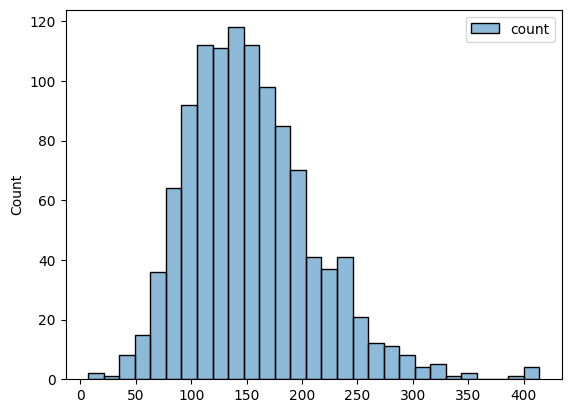

In [22]:
#original tile distribution
sns.histplot(lib1map[0].value_counts().to_frame())
print(len(lib1map[0].value_counts().to_frame()))

/global/home/users/sanjanakotha/.conda/envs/sog1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/sanjanakotha/.conda/envs/sog1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/global/home/users/sanjanakotha/.conda/envs/sog1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


11345


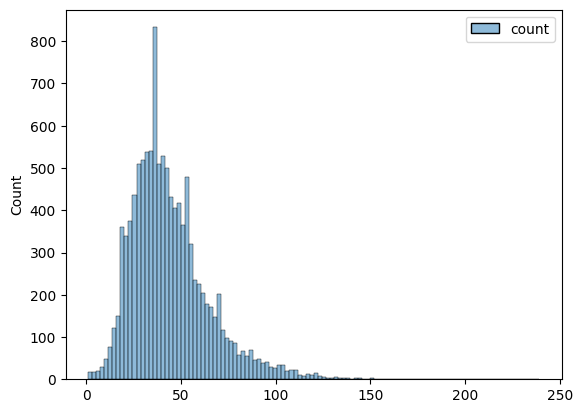

In [23]:
# original tile distribution
sns.histplot(lib2map[0].value_counts().to_frame())
print(len(lib2map[0].value_counts().to_frame()))

1112


/global/home/users/sanjanakotha/.conda/envs/sog1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/sanjanakotha/.conda/envs/sog1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/global/home/users/sanjanakotha/.conda/envs/sog1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


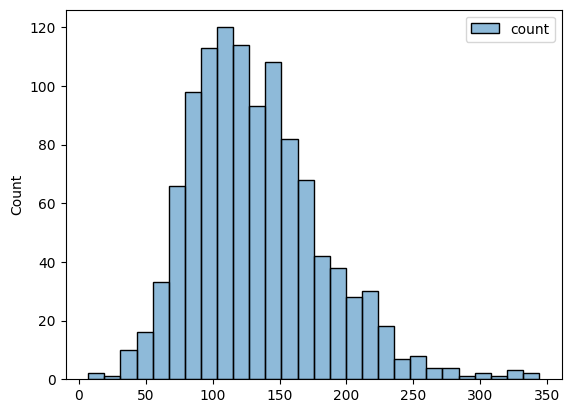

In [24]:
# filtered tile distribution (lib1 tiles)
#original tile distribution
sns.histplot(bothlibsmap_fil['0_x'].value_counts().to_frame())
print(len(bothlibsmap_fil['0_x'].value_counts().to_frame()))

/global/home/users/sanjanakotha/.conda/envs/sog1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/sanjanakotha/.conda/envs/sog1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/global/home/users/sanjanakotha/.conda/envs/sog1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


11344


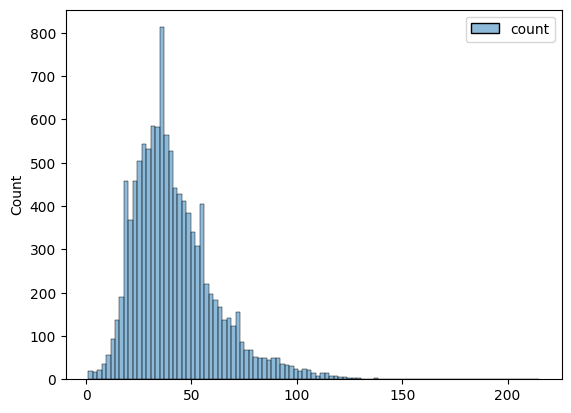

In [25]:
# filtered tile distribution (lib2 tiles)
#original tile distribution
sns.histplot(bothlibsmap_fil['0_y'].value_counts().to_frame())
print(len(bothlibsmap_fil['0_y'].value_counts().to_frame()))

## Consolidate

In [26]:
cols=['0_x', '0_y']
bothlibsmap_fil['Tiles'] = bothlibsmap_fil[cols].bfill(axis=1).iloc[:,0]
bothlibsmap_fil = bothlibsmap_fil[['index', 'Tiles']]
bothlibsmap_fil

,index,Tiles
0,AAAAAAAAAAA,GCTTTGTGTGATGAGTTCTTGTTGGCTCAAGCTCAAACTTCTTGTG...
1,AAAAAAAAAAC,CAGAAGATTGTCTTGGATCCATCTAATATTGAAGCTGATACTCCAC...
2,AAAAAAAAAAG,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGATGCTA...
3,AAAAAAAAACA,GGTTCTCAAGCTAGAGAAGAGAATACTAATTCTGGTTCTTTGAAAG...
4,AAAAAAAAACC,GCTGAATTTATTCCAACTGTTAATCAAGATGCTGGTATTTGTTATA...
...,...,...
623665,TTTTTTTGTGC,AGATTGGCTAGAGTCTTGTTCTTGCATTTGTATTTGTTCTTGACTA...
623666,TTTTTTTTGAT,CAACAACCACAACAATTGGTTGTTGGTGGTGGTGGTGGTGCTGGTC...
623667,TTTTTTTTGGC,GTTGCTATGGCTCATGCTGATGCTTTGGATGACTTTGATTTGGATA...
623668,TTTTTTTTTCG,CAATATAAAGAAGGTCAGAATGGTGGTGGTACTAGATCTCAATTCT...


In [27]:
bothlibsmap_fil = bothlibsmap_fil.set_index('index')
bothlibsmap_fil = bothlibsmap_fil.T
bothlibsmap_fil

index,AAAAAAAAAAA,AAAAAAAAAAC,AAAAAAAAAAG,AAAAAAAAACA,AAAAAAAAACC,AAAAAAAAACG,AAAAAAAAACT,AAAAAAAAAGG,AAAAAAAAAGT,AAAAAAAAATA,...,TTTTTTTGATC,TTTTTTTGATT,TTTTTTTGCTA,TTTTTTTGCTG,TTTTTTTGTCC,TTTTTTTGTGC,TTTTTTTTGAT,TTTTTTTTGGC,TTTTTTTTTCG,TTTTTTTTTTT
Tiles,GCTTTGTGTGATGAGTTCTTGTTGGCTCAAGCTCAAACTTCTTGTG...,CAGAAGATTGTCTTGGATCCATCTAATATTGAAGCTGATACTCCAC...,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGATGCTA...,GGTTCTCAAGCTAGAGAAGAGAATACTAATTCTGGTTCTTTGAAAG...,GCTGAATTTATTCCAACTGTTAATCAAGATGCTGGTATTTGTTATA...,AGGAAGATGGAAGTCTTGGCTGTTGATGATGAAGATTGTGAACCAT...,GGTGTTGCTGGTGATGAAGAAGCATTTGATGATTTGAAGATGTTTG...,CAGAAGATTGTCTTGAATCCATCTAATATTCAAGCTAATACTCCAC...,CAGAAGATTGTCTTGGATCCATCTAATATTGAATTGGATGCTCCAC...,CCAGGTATGGAGAATCATGTTGATCAAATGGTTGGTGATAATGATA...,...,GAAGATCCAGCTTGGTTTGATGATGATGCTGACTTTGATTTGGATG...,CAGAAGATTGTCTTGGATCCAGAAGAAATTGAATTGGATGAAGAAC...,GCTACTCCAACTGTTGCTGCATTTATTGATGATCCAGTTACTCCTA...,AAGAAATTGAGAGTTAATGCTATTGGTGTTGTTGATGTTTATAAAG...,CCACAGAACTTTAGGAAATACTTTACTGCATTTAATTCTAACTTTG...,AGATTGGCTAGAGTCTTGTTCTTGCATTTGTATTTGTTCTTGACTA...,CAACAACCACAACAATTGGTTGTTGGTGGTGGTGGTGGTGCTGGTC...,GTTGCTATGGCTCATGCTGATGCTTTGGATGACTTTGATTTGGATA...,CAATATAAAGAAGGTCAGAATGGTGGTGGTACTAGATCTCAATTCT...,GACTTTAAGAGAGATTTGGAAGAGAATATTGTTTGTTTGCAATCTG...


In [28]:
print(bothlibsmap_fil)

index                                        AAAAAAAAAAA  \
Tiles  GCTTTGTGTGATGAGTTCTTGTTGGCTCAAGCTCAAACTTCTTGTG...   

index                                        AAAAAAAAAAC  \
Tiles  CAGAAGATTGTCTTGGATCCATCTAATATTGAAGCTGATACTCCAC...   

index                                        AAAAAAAAAAG  \
Tiles  TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGATGCTA...   

index                                        AAAAAAAAACA  \
Tiles  GGTTCTCAAGCTAGAGAAGAGAATACTAATTCTGGTTCTTTGAAAG...   

index                                        AAAAAAAAACC  \
Tiles  GCTGAATTTATTCCAACTGTTAATCAAGATGCTGGTATTTGTTATA...   

index                                        AAAAAAAAACG  \
Tiles  AGGAAGATGGAAGTCTTGGCTGTTGATGATGAAGATTGTGAACCAT...   

index                                        AAAAAAAAACT  \
Tiles  GGTGTTGCTGGTGATGAAGAAGCATTTGATGATTTGAAGATGTTTG...   

index                                        AAAAAAAAAGG  \
Tiles  CAGAAGATTGTCTTGAATCCATCTAATATTCAAGCTAATACTCCAC...   

index                           

In [51]:
# @sanjana please run <3
bothlibsmap_fil.to_csv('../output/sog1_lib1+2map_EC20250403.csv', index=False) #keeps killing the kernel

# Analyze FACS data (CZB_Jan2024/MYS3/feb7)
- analysis steps taken from Process_Sog_sort3.ipynb and E2FA & GCN4.ipynb on local (/Users/emilychase/Desktop/StallerLab/Sog1_lib2_analysis/from_jordan) but recapitulated as /global/scratch/projects/fc_mvslab/data/sequencing/CZB_Feb2024/Sog1_Lib2_map/map_outputs/Sort_analysis_v1.ipynb here on savio

In [61]:
mys3path = '/global/scratch/projects/fc_mvslab/data/sequencing/CZB_Jan2024/MYS3/feb7/'
# gdnamappath = '/global/scratch/projects/fc_mvslab/data/sequencing/CZB_Feb2024/Sog1_Lib2_map/map_outputs/'
mapfpath_lib2 = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/sog1/EC_analysis/sog1_lib2_barcode_map_EC.csv'
mapfpath_all = '../output/sog1_lib1+2map_EC20250403.csv'#whenever we can save the bothlibsmap_fil to csv

In [62]:
# pd.read_csv(mapfpath_lib2)

## Process the sort
processed data saved as csv files testgfp[1,2]\_*\_.csv

In [63]:
# USE READ 1 NOT ASSEMBLED

datanames_gfp8 = ["MYS3_001_S1_R1_001.fastq",
                 "MYS3_002_S2_R1_001.fastq",
                 'MYS3_003_S3_R1_001.fastq',
                 'MYS3_004_S4_R1_001.fastq',
                 'MYS3_005_S5_R1_001.fastq',
                 'MYS3_006_S6_R1_001.fastq',
                 'MYS3_007_S7_R1_001.fastq',
                 'MYS3_008_S8_R1_001.fastq']
datafiles_gfp8 = []
for f in datanames_gfp8:
    fpath = mys3path + f
    datafiles_gfp8.append(fpath)

# print(datafiles_gfp8)
bin_counts = [100,100,100,100,100,100,100,100]
bin_values_gfp8 = [146,237,331,483,776,1364,2592,6357]
gfp8wayfiles = Sort(datafiles_gfp8, bin_counts, bin_values_gfp8, bc_dict = mapfpath_all)

In [64]:
#gfp1_activity, gfp1_reads, gfp1_bins, gfp1_loss_table = gfp8wayfiles.process(bc_anteceder = "GGCGCGCC")
gfp1_activity, gfp1_reads, gfp1_bins = gfp8wayfiles.process(bc_anteceder = "GGCGCGCC")

Opening file MYS3_001_S1_R1_001.fastq ...
Total parsed reads = 119,788,454                      
Opening file MYS3_002_S2_R1_001.fastq ...
Total parsed reads = 116,842,528                      
Opening file MYS3_003_S3_R1_001.fastq ...
Total parsed reads = 135,400,512                      
Opening file MYS3_004_S4_R1_001.fastq ...
Total parsed reads = 139,455,679                      
Opening file MYS3_005_S5_R1_001.fastq ...
Total parsed reads = 121,908,963                      
Opening file MYS3_006_S6_R1_001.fastq ...
Total parsed reads = 150,376,570                      
Opening file MYS3_007_S7_R1_001.fastq ...
Total parsed reads = 140,260,726                      
Opening file MYS3_008_S8_R1_001.fastq ...
Total parsed reads = 128,817,384                      


In [65]:
#save to txt files 
# @ sanjana this was bc the above code takes a long time and I didn't want to have to monitor my jupyter notebook. Feel free to change the names/file paths

#activity
gfp1_activity.to_csv('../output/testgfp1_activity_SK.csv')

# # loss table
# with open("../output/testgfp1_losstable_SK.txt", 'w') as f:  
#     for key, value in gfp1_loss_table.items():  
#         f.write('%s:%s\n' % (key, value))

#reads
gfp1_reads.to_csv('../output/testgfp1_readsseries_SK.csv')
#bins
gfp1_bins.to_csv('../output/testgfp1_bins_SK.csv')

In [68]:
datanames_gfp8_2 = ["MYS3_013_S13_R1_001.fastq",
                 "MYS3_014_S14_R1_001.fastq",
                 'MYS3_015_S15_R1_001.fastq',
                 'MYS3_016_S16_R1_001.fastq',
                 'MYS3_017_S17_R1_001.fastq',
                 'MYS3_018_S18_R1_001.fastq',
                 'MYS3_019_S19_R1_001.fastq',
                 'MYS3_020_S20_R1_001.fastq']
datafiles_gfp8_2 = []
for f in datanames_gfp8_2:
    fpath = mys3path + f
    datafiles_gfp8_2.append(fpath)

# print(datafiles_gfp8)
bin_counts = [100,100,100,100,100,100,100,100]
bin_values_gfp8 = [146,237,331,483,776,1364,2592,6357]
gfp8wayfiles_2 = Sort(datafiles_gfp8_2, bin_counts, bin_values_gfp8, bc_dict = mapfpath_lib2)

In [71]:
gfp2_activity, gfp2_reads, gfp2_bins = gfp8wayfiles_2.process(bc_anteceder = "GGCGCGCC")

Opening file MYS3_013_S13_R1_001.fastq ...
Total parsed reads = 128,184,144                      
Opening file MYS3_014_S14_R1_001.fastq ...
Total parsed reads = 131,229,614                      
Opening file MYS3_015_S15_R1_001.fastq ...
Total parsed reads = 109,736,574                      
Opening file MYS3_016_S16_R1_001.fastq ...
Total parsed reads = 126,243,880                      
Opening file MYS3_017_S17_R1_001.fastq ...
Total parsed reads = 142,348,607                      
Opening file MYS3_018_S18_R1_001.fastq ...
Total parsed reads = 150,896,403                      
Opening file MYS3_019_S19_R1_001.fastq ...
Total parsed reads = 145,064,102                      
Opening file MYS3_020_S20_R1_001.fastq ...
Total parsed reads = 115,906,436                      


In [73]:
#save to txt files
#activity
gfp2_activity.to_csv('../output/testgfp2_activity_SK.csv')
# loss table
# with open("../output/testgfp2_losstable_SK.txt", 'w') as f:  
#     for key, value in gfp2_loss_table.items():  
#         f.write('%s:%s\n' % (key, value))
#reads
gfp2_reads.to_csv('../output/testgfp2_readsseries_SK.csv')
#bins
gfp2_bins.to_csv('../output/testgfp2_bins_SK.csv')

## Analyze sort quality

In [75]:
# start from here aug 22
gfp1_activity = pd.read_csv('../output/testgfp1_activity_SK.csv', index_col='AD')
gfp1_reads = pd.read_csv('../output/testgfp1_readsseries_SK.csv', index_col='AD').squeeze()
# gfp1_reads = gfp1_reads.squeeze()
gfp1_bins = pd.read_csv('../output/testgfp1_bins_SK.csv', index_col='AD')

gfp2_activity = pd.read_csv('../output/testgfp2_activity_SK.csv', index_col='AD')
gfp2_reads = pd.read_csv('../output/testgfp2_readsseries_SK.csv', index_col='AD').squeeze()
gfp2_bins = pd.read_csv('../output/testgfp2_bins_SK.csv', index_col='AD')

In [76]:
# merge read counts
d = pd.DataFrame(gfp1_reads).merge(pd.DataFrame(gfp2_reads), on = "AD", how = 'outer').reset_index().rename(columns= {"AD":"ArrayDNA","0_x":"reads_S3_1","0_y":"reads_S3_2"})
d.head()

,ArrayDNA,reads_S3_1,reads_S3_2
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,608.0,643.0
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,44353.0,36001.0
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,68.0,38.0
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,5086.0,7330.0
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,170.0,137.0


In [77]:
# # imported Sog1_all_activities_and_tiles_EC_unpublisheddatadownload.csv from local after downloading from drive (originally Sog1_all_activities_and_tiles.csv)
# old_tiles = pd.read_csv("Sog1_all_activities_and_tiles_EC_unpublisheddatadownload.csv", usecols=['Activity_GFP8', 'ArrayDNA_y'])
# old_tiles = old_tiles.rename(columns={'ArrayDNA_y':'ArrayDNA'})

In [78]:
to_merge = gfp1_activity.reset_index(names = "ArrayDNA")[["ArrayDNA", "Activity"]].rename(columns = {'Activity':"Activity_S3_1"})
# n = old_tiles.merge(to_merge, on = "ArrayDNA", how = 'outer')
to_merge2 = gfp2_activity.reset_index(names = "ArrayDNA")[["ArrayDNA", "Activity"]].rename(columns = {'Activity':"Activity_S3_2"})
# c = n.merge(to_merge2, on = "ArrayDNA", how = 'outer').merge(d, on = "ArrayDNA", how = 'outer')
c = to_merge.merge(to_merge2, on = "ArrayDNA", how = 'outer').merge(d, on = "ArrayDNA", how = 'outer')

In [79]:
c.head()

,ArrayDNA,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,1106.567900,925.703811,608.0,643.0
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,1406.746740,1424.548173,44353.0,36001.0
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,1393.949144,1170.193129,68.0,38.0
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,283.112716,267.611412,5086.0,7330.0
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,4090.212610,3163.539743,170.0,137.0


In [80]:
ex = c[["ArrayDNA", "Activity_S3_1", "Activity_S3_2", "reads_S3_1", "reads_S3_2"]].copy(deep = True)
ex['AAseq'] = [str(Seq(x).translate()) for x in ex.ArrayDNA]
ex["lib2_avg"] = ex[['Activity_S3_1', 'Activity_S3_2']].mean(axis = 1)
ex["lib2_std"] = ex[['Activity_S3_1', 'Activity_S3_2']].std(axis = 1)

In [82]:
# @ sanjana, save and name however makes sense!
# save tile/AAseq, activities, read counts, and their avg/std stats into a csv
ex.to_csv("../output/Sog1_library2_activities_with_reads_SK.csv", index = None)

# Various analysis
Not well documented, but I'm keeping it in here in case it's helpful haha

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


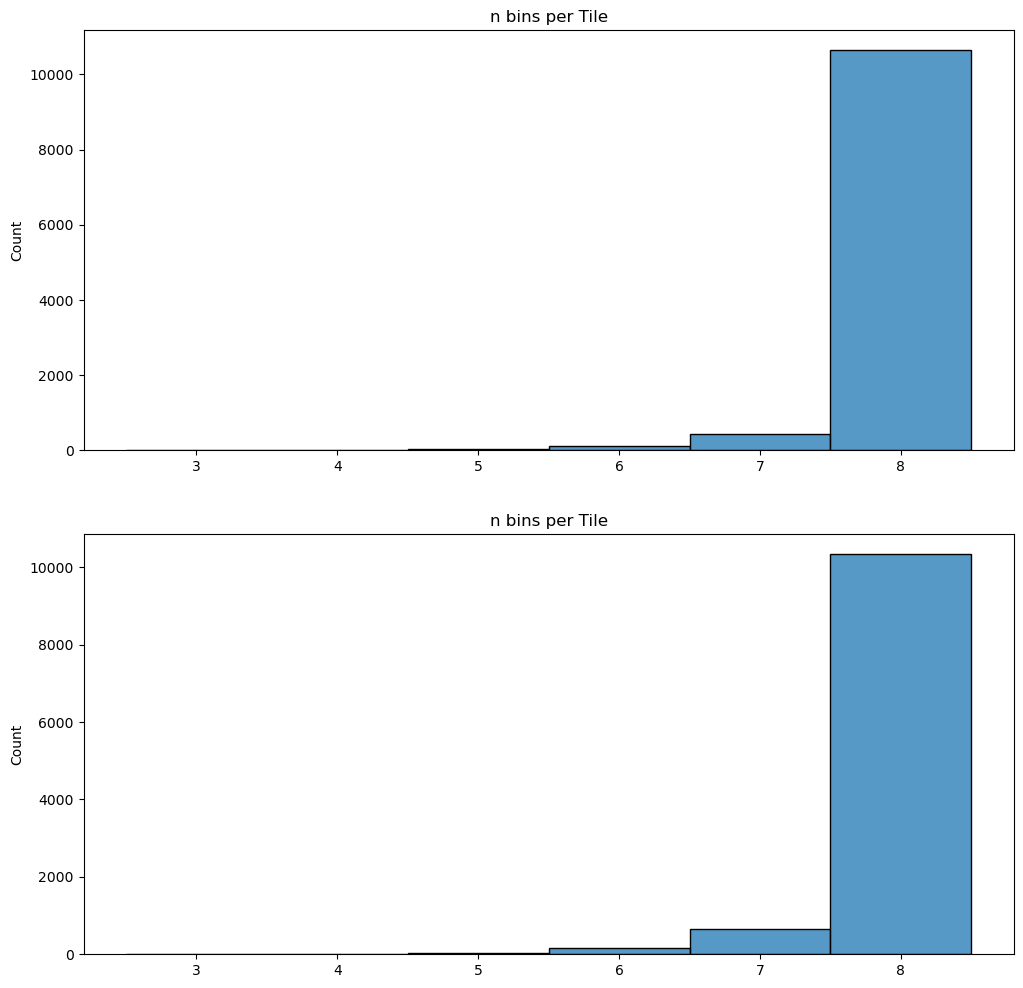

In [26]:
fix, axes = plt.subplots(2,1, figsize = (12,12))
for file, ax in zip([gfp1_bins,gfp2_bins], [axes[0],axes[1]]):
    df = file
    df['n_bins'] = df[df > 0].iloc[:,:-2].count(axis = 1)
    df["n_reads"] = df.sum(axis = 1)
    sns.histplot(df[df > 0].iloc[:,:-2].count(axis = 1), bins = 8, discrete = True,ax = ax)
    ax.set_title(f'n bins per Tile')

<Axes: xlabel='n_bins', ylabel='n_reads'>

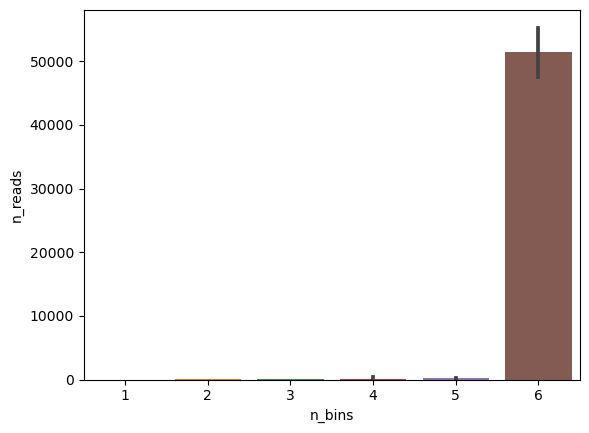

In [27]:
sns.barplot(data = gfp1_bins, x = "n_bins", y = "n_reads")

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='n_reads', ylabel='Count'>

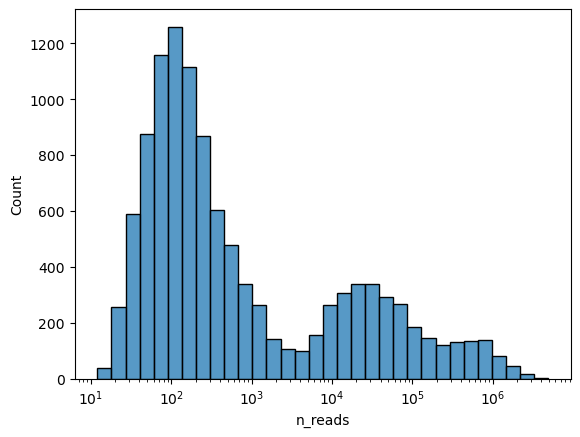

In [28]:
sns.histplot(gfp2_bins.n_reads, log_scale=True)

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr

# colors 
orange = (1.0, 0.41, 0.12)
alt_orange = (0.6, 0.21, 0.02)
burgundy = (0.6, 0.15, 0.15)
purple = (0.3, 0.16, 0.61)
teal = (0.26, 0.72, 0.73)
alt_teal = (0.16, 0.4, 0.4)
navy = (0.11, 0.16, 0.27)
gray = (0.49, 0.49, 0.49)
pink = (1.0, 0.08, 0.58)  # Define pink color

lin = LinearRegression()

def compare(X, Y, scores, color = navy, titles = None, x = 100, y = 15000, gridsize = 60, opt = '', line = True, title = None):
    plt.figure(1, dpi = 400)

    """
    X & Y: columns in a df
    scores: df with the columns you want to compare
    """
    
    scores = scores[[X,Y]].dropna(how='any')
    
    lin.fit(scores[[X]], scores[[Y]])
    sns.jointplot(data = scores, x = X, y = Y, color = color, kind = 'scatter')
    
    # Add the regression line if line=True
    if line:
        sns.regplot(data = scores, x = X, y = Y, scatter= False, ci = None, line_kws = {'color':navy, 'alpha':0.9}, truncate = True)
    
    # Add the y=x line in pink
    min_val = min(scores[[X, Y]].min())  # Find the minimum value for both X and Y
    max_val = max(scores[[X, Y]].max())  # Find the maximum value for both X and Y
    plt.plot([min_val, max_val], [min_val, max_val], color=pink, linestyle='--', label='y=x')

    cod = round(lin.score(scores[[X]], scores[[Y]]), 3)
    spearman = round(spearmanr(scores[[X]],scores[[Y]])[0], 3)
    
    if titles is not None:
        X = titles[0]
        Y = titles[1]
        plt.xlabel(titles[0])
        plt.ylabel(titles[1])
    
    plt.title(title, fontsize = 14, y = -0.17)
    plt.text(x,y, f"R^2 = {cod} \nSpearman: {spearman}\nNum shared tiles: {len(scores)}", fontsize = 12, bbox= {'color':'white','alpha':0.7})
    # plt.legend()
    plt.tight_layout()
    
    if opt != '':
        plt.suptitle(opt, color='red', va='bottom')
    
    opt = opt+'_'
    # plt.savefig(f"./figures/{Y.replace(' ','_')}_v_{X.replace(' ','_')}{opt.replace(' ','_')}sog1_lib2_EC.svg")


In [16]:
# compare("Activity_S3_1", "Activity_GFP8", y = 8000, titles = ["Activity Sog1 Library 2, Sort 3", "Activity Margot Library 1"], 
#        title = "Library 1 tiles measured in both sorts")

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 2560x1920 with 0 Axes>

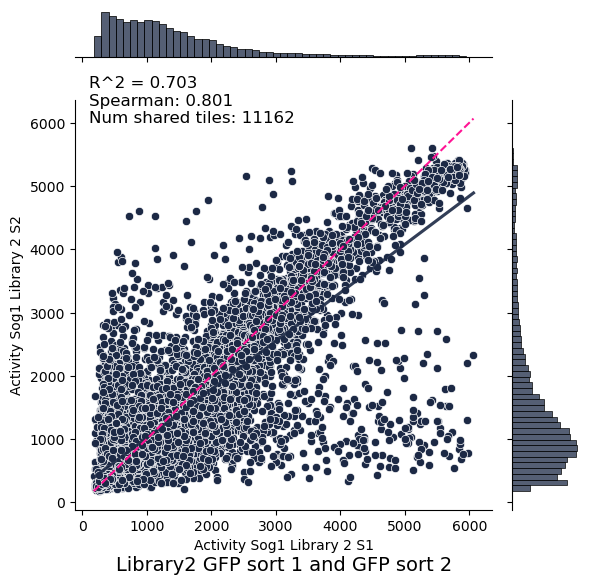

In [33]:
compare("Activity_S3_1", "Activity_S3_2", c, y = 6000, titles = ["Activity Sog1 Library 2 S1", "Activity Sog1 Library 2 S2"], 
       title = "Library2 GFP sort 1 and GFP sort 2")

In [18]:
reads = pd.DataFrame([gfp1_reads, gfp2_reads])
reads.index=[0,1]
reads = reads.transpose()
reads.median()

0    362.0
1    223.0
dtype: float64

In [19]:
reads.head()

,0,1
AD,,
AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGTTTCAATCTGGTTCTCAATTTATCTTAAATTCTCAACAATTGGTTCAAGCTTTGTCTTTGTGTCAACAATTGTTG,610.0,643.0
AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATTCTCAACAATTGGTTGAAGCTTTGTCTTTGTGTGATGATTTGTTG,44354.0,36001.0
AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTGATCCAGCTGCTTTGAAGAGAGCTAGAAATACTGAAGCTGCTAGAAGATCTAGAGCTAGGAAATTGCAAAGAATG,68.0,38.0
AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAGTTTCTTCTGTTGGTGAGAAAGAATGGTACTTCTTCTGTATGAGAGGTAGGAAATATAGAAATTCTGTTAGACCA,5090.0,7330.0
AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCACCAGAATTTAGATTGTCTCAATTGGAATTTGGTTCTCAAGATTCATTCTTGGCTTGGGGTACTGGTAAGACTGAT,172.0,137.0


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to 

Text(300000, 2000, 'Mean:\n0    49286.312317\n1    53560.606115\n\nMedian:\n0    362.0\n1    223.0\n\nMax:\n0    3858390.0\n1    4881825.0\n\nStandard Deviation:\n0    202464.273442\n1    225336.443621')

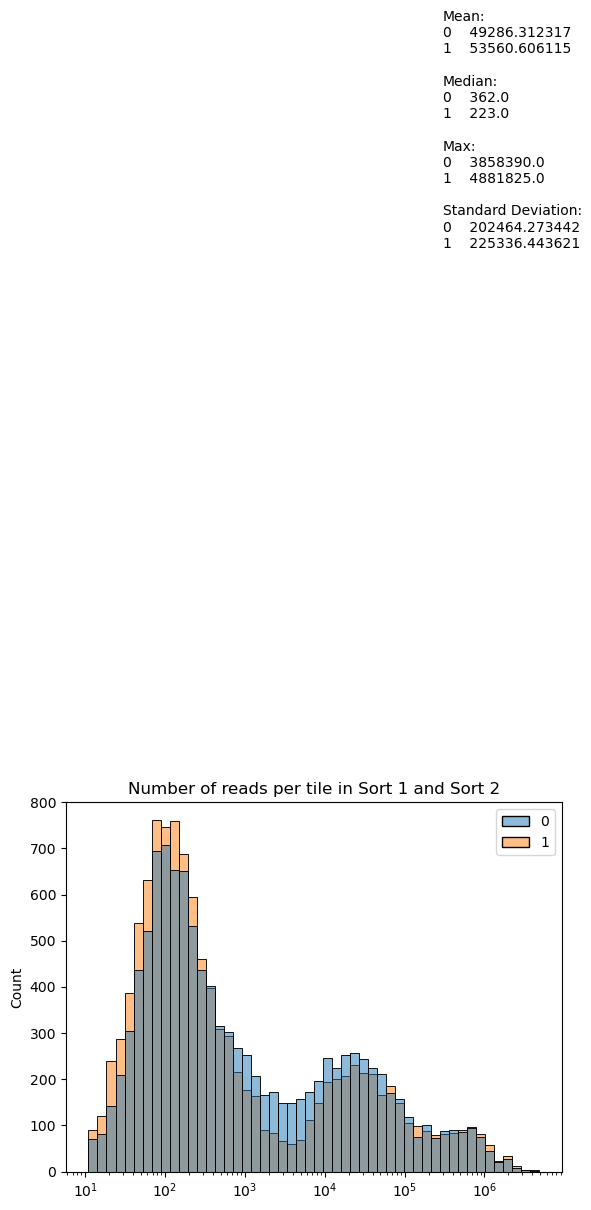

In [20]:
sns.histplot(reads, bins = 50, log_scale=True)
plt.title("Number of reads per tile in Sort 1 and Sort 2")
plt.text(300000,2000, f"Mean:\n{reads.mean().to_string()}\n\nMedian:\n{reads.median().to_string()}\n\nMax:\n{reads.max().to_string()}\n\nStandard Deviation:\n{reads.std().to_string()}")
# plt.savefig("figures/sog1_lib2_reads.svg")

## Find Gcn4 tile activities

In [7]:
fromjordan = '/global/scratch/projects/fc_mvslab/data/sequencing/CZB_Feb2024/Sog1_Lib2_map/map_outputs/from_jordan/'

activities = pd.read_csv("Sog1_library2_activities_with_reads_ECspike.csv") # this csv file came from "Analyze sort quality" - made up of sort data from '/global/scratch/projects/fc_mvslab/data/sequencing/CZB_Jan2024/MYS3/feb7/'
# e2fa_tiles = pd.read_csv("from_jordan/e2fa_tiles.csv", sep = ";")
gcn4_tiles = pd.read_csv(f"{fromjordan}GCN4_phosphovariants_max_lists.csv", sep = ";")

In [8]:
activities.head()

,ArrayDNA,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,1079.074274,925.703811,610.0,643.0,KQRQNQNQGQQQPTWFQSGSQFILNSQQLVQALSLCQQLL,1002.389042,108.449295
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,1394.076068,1424.548173,44354.0,36001.0,KQRDNEDNGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1409.312120,21.547032
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,1371.861742,1170.193129,68.0,38.0,KQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRM,1271.027436,142.601244
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,283.663233,267.611412,5090.0,7330.0,KQIDIYKYDPWDLPRVSSVGEKEWYFFCMRGRKYRNSVRP,275.637323,11.350351
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,4076.691936,3163.539743,172.0,137.0,KQIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,3620.115839,645.696108


In [9]:
# e2fa_tiles['AAseq'] = [x.upper() for x in e2fa_tiles.tile]
gcn4_tiles['AAseq'] = [x.upper() for x in gcn4_tiles.tile]

In [10]:
maptiles = pd.read_csv('sog1_lib2_barcode_map_EC.csv', header=None).T #spikein-generated map
maptiles = maptiles.rename(columns={0:'BC', 1:'ArrayDNA'})
maptiles['AAseq'] = [str(Seq(x).translate()) for x in maptiles.ArrayDNA]
maptiles_grouped = maptiles.groupby('AAseq').first().reset_index()

merged_df = pd.merge(gcn4_tiles, maptiles_grouped, on='AAseq', how='left')
merged_df.head()

/tmp/ipykernel_411040/1419320031.py:1: DtypeWarning: Columns (500102) have mixed types. Specify dtype option on import or set low_memory=False.
  maptiles = pd.read_csv('sog1_lib2_barcode_map_EC.csv', header=None).T #spikein-generated map


,ortholog_tile_name,tile,subgroup,AAseq,BC,ArrayDNA
0,GCN4_CAAD40,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,WT_GCN4_ortholog,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,GTCAGACAGGC,TCTACTGATTCTACTCCAATGTTTGAATATGAGAATTTGGAAGATA...
1,GCN4_CAAD40,STDSdpMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,full_pmim,STDSDPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,CACTTCAGCTA,TCTACTGATTCTGATCCAATGTTTGAATATGAGAATTTGGAAGATA...
2,GCN4_CAAD40,STDSapMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,full_pmut,STDSAPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,CCTTCAAGTCG,TCTACTGATTCTGCTCCAATGTTTGAATATGAGAATTTGGAAGATA...
3,War1_Cterm,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,WT_GCN4_ortholog,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,CAATCCCTCGT,CCATCTCCATCTTCTTCTGTTGATAATTTGAATGATTATTTGACTG...
4,War1_Cterm,PdpSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,full_pmim,PDPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,TGGATCACCCT,CCAGATCCATCTTCTTCTGTTGATAATTTGAATGATTATTTGACTG...


In [11]:
maptiles.shape

(500761, 3)

In [12]:
merged_df['PresentinMap'] = np.where(merged_df['ArrayDNA'].notna(), 1, 0)
# merged_df.head()

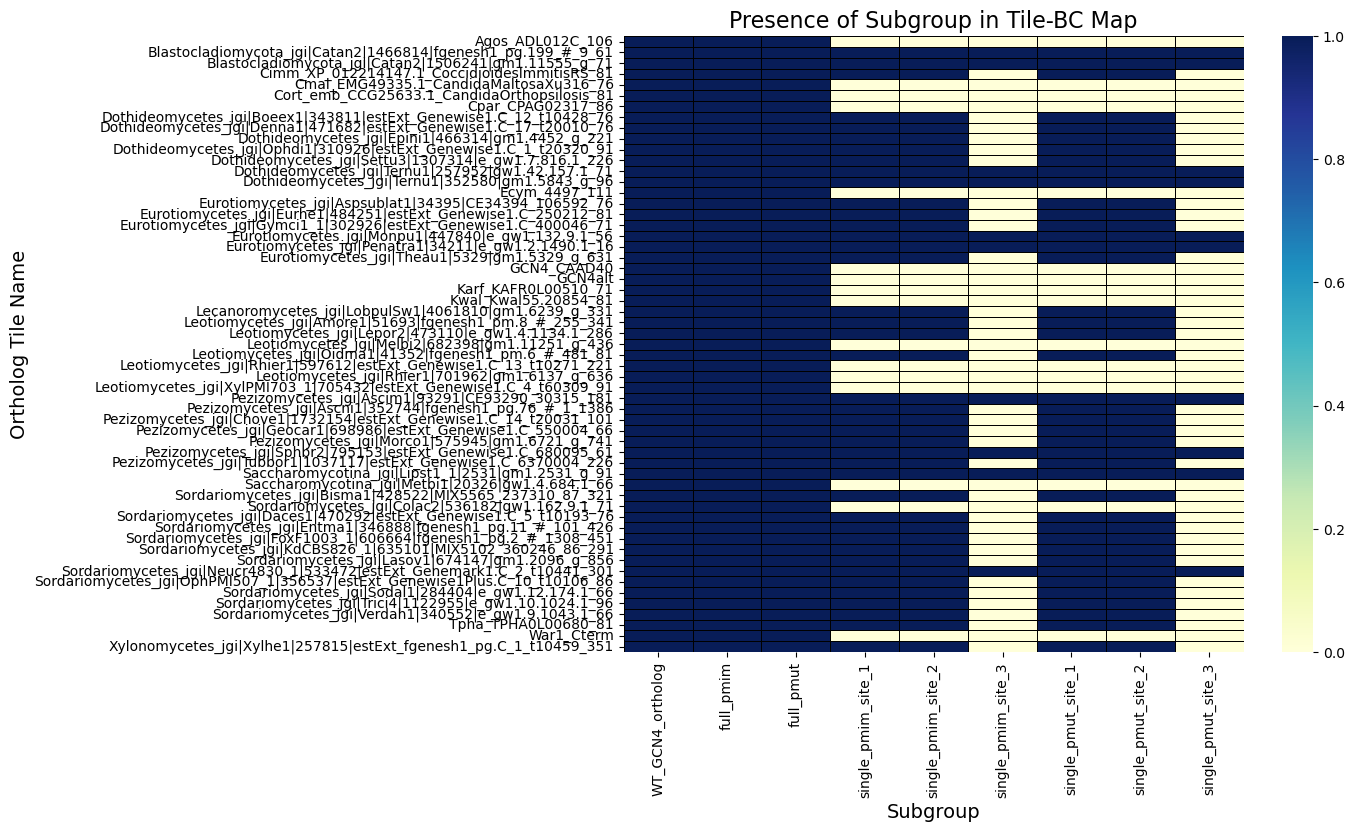

In [13]:
# Pivot the data to prepare it for a heatmap

heatmap_data = merged_df.pivot_table(index='ortholog_tile_name', 
                                     columns='subgroup', values='PresentinMap', 
                                     fill_value=0, )
                                    

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', 
            linewidths=0.5, linecolor='black', 
             cbar=True,
           xticklabels=True, yticklabels=True)

# Titles and labels
plt.title('Presence of Subgroup in Tile-BC Map', fontsize=16)
plt.xlabel('Subgroup', fontsize=14)
plt.ylabel('Ortholog Tile Name', fontsize=14)

plt.show()

In [14]:
gcn4tilesinmap = merged_df[~merged_df['ArrayDNA'].isna()]

In [15]:
gcn4tilesinmap['subgroup'].value_counts().to_frame().reset_index()

,subgroup,count
0,WT_GCN4_ortholog,60
1,full_pmim,60
2,full_pmut,60
3,single_pmim_site_1,43
4,single_pmut_site_1,43
5,single_pmim_site_2,43
6,single_pmut_site_2,43
7,single_pmim_site_3,11
8,single_pmut_site_3,11


In [16]:
gcn4_tiles['subgroup'].value_counts().to_frame().reset_index()

,subgroup,count
0,WT_GCN4_ortholog,60
1,full_pmim,60
2,full_pmut,60
3,single_pmim_site_1,43
4,single_pmut_site_1,43
5,single_pmim_site_2,43
6,single_pmut_site_2,43
7,single_pmim_site_3,11
8,single_pmut_site_3,11


In [17]:
# e2fa = e2fa_tiles.merge(activities, how = 'inner', on = 'AAseq')
# e2fa = e2fa[['tf_name','start','end','AAseq','tile','subgroup','lib2_avg','Activity_S3_1','Activity_S3_2','reads_S3_1', 'reads_S3_2','lib2_std','ArrayDNA']]

gcn4 = gcn4_tiles.merge(activities, how = 'inner', on = 'AAseq') # this df is the activity data but just for gcn4
# gcn4 = merged_df.merge(activities, how = 'inner', on = 'AAseq')
gcn4 = gcn4[['ortholog_tile_name','AAseq','tile','subgroup','lib2_avg','Activity_S3_1','Activity_S3_2','reads_S3_1', 'reads_S3_2','lib2_std','ArrayDNA']]
# gcn4 = gcn4[['ortholog_tile_name','AAseq','tile','subgroup','lib2_avg','Activity_S3_1','Activity_S3_2','reads_S3_1', 'reads_S3_2','lib2_std','PresentinMap']]

gcn4[['ortholog_tile_name', "tile", "subgroup", "Activity_S3_1", "Activity_S3_2",'reads_S3_1', 'reads_S3_2']][gcn4.ortholog_tile_name != "War1_Cterm"].iloc[0:6]

,ortholog_tile_name,tile,subgroup,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2
0,GCN4_CAAD40,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,WT_GCN4_ortholog,975.339096,696.700377,23.0,25.0
1,GCN4_CAAD40,STDSdpMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,full_pmim,472.106028,424.199871,615630.0,744008.0
2,GCN4_CAAD40,STDSapMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,full_pmut,3931.409814,4246.908563,41372.0,45165.0
6,GCN4alt,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,WT_GCN4_ortholog,389.471551,405.059168,1262.0,1508.0
7,GCN4alt,DDAVVESFFSSSTDSdpMFEYENLEDNSKEWTSLFDNDIP,full_pmim,1633.022796,958.617105,81.0,64.0
8,GCN4alt,DDAVVESFFSSSTDSapMFEYENLEDNSKEWTSLFDNDIP,full_pmut,696.494336,737.696446,52.0,62.0


In [18]:
gcn4.shape

(372, 11)

In [33]:
# good_e2fa = e2fa[(e2fa.reads_S3_1 > 100) & (e2fa.reads_S3_2 > 100)]
# def getgroup(group,subgroup=None, tile=None, tile_id = False):
#     data = good_e2fa.where(good_e2fa.subgroup == group).dropna(how="all")
#     return data

In [19]:
# colors 
orange = (1.0, 0.41, 0.12)
alt_orange = (0.6, 0.21, 0.02)
#purple = (0.3, 0.16, 0.61)
purple = (0.44,0.37,0.85)
teal = (0.26, 0.72, 0.73)
alt_teal = (0.16, 0.4, 0.4)
navy = (0.11, 0.16, 0.27)
gray = (0.49, 0.49, 0.49)

# neg = red
#burgundy = (0.6, 0.15, 0.15)
burgundy = (0.50,0.00,0.33)

# pos = blue
alt_navy = (0.1, 0.2, 0.55)

In [93]:
# # Main phosphosite plot 

# sns.set_palette([purple])

# fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

# # add data 
# sns.lineplot(x='start', y='lib2_avg', data=getgroup("WT_e2fa"), linewidth = 4, color = purple)
# sns.lineplot(x='start', y='lib2_avg', data=getgroup("full_pmut"), linewidth=4, color = teal)
# sns.lineplot(x='start', y='lib2_avg', data=getgroup("full_pmim"), linewidth=3, color = burgundy)

# # add squares for legend markers
# rect1 = mlines.Line2D([], [], marker="s", markersize=25, linewidth=0, color=purple)
# rect2 = mlines.Line2D([], [], marker="s", markersize=25, linewidth=0, color=teal)
# rect3 = mlines.Line2D([], [], marker="s", markersize=25, linewidth=0, color=burgundy)

# # add top legend
# axes.legend(handles = [rect1, rect2, rect3], labels = ['Wild type', 'Phosphomutant', "Phosphomimetic"], fontsize = 15, ncol=3, 
#             bbox_to_anchor = [1.06,1.13], handlelength=0.5, frameon = False, handletextpad = 1.2)

# # titles and labels 
# axes.set_title(label="E2FA Full Phosphosite Tiles", y= 1.13, size = 20)
# axes.set_ylabel(ylabel="Activity", fontsize = 18, labelpad=10)
# axes.set_xlabel(xlabel="E2FA Position", fontsize = 18, labelpad=10)

# # tick formatting
# plt.tick_params(length = 10)
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
# plt.ylim(0,6000)

# # margin adjustment
# plt.subplots_adjust(wspace=0, hspace=0.05)

# #plt.savefig("./figures/sort_2/WT_GFP_phosphosites.png")

In [20]:
def getgroup(group,subgroup=None, tile=None, tile_id = False):
    data = gcn4.where(gcn4.subgroup == group).dropna(how="all")
    return data


In [21]:
gcn4_orthos = gcn4[gcn4.subgroup.isin(['WT_GCN4_ortholog','full_pmim','full_pmut'])]
good_gcn4 = gcn4[(gcn4.reads_S3_1 > 100) & (gcn4.reads_S3_2 > 100)].head(50)
good_gcn4_all = gcn4[(gcn4.reads_S3_1 > 100) & (gcn4.reads_S3_2 > 100)] # may need to adjust this to threshold properly
# good_gcn4_all = gcn4[(gcn4.PresentinMap == 1) & (gcn4.reads_S3_1 > 50) & (gcn4.reads_S3_2 > 50)]

In [22]:
gcn4_orthos

,ortholog_tile_name,AAseq,tile,subgroup,lib2_avg,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,lib2_std,ArrayDNA
0,GCN4_CAAD40,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,WT_GCN4_ortholog,836.019736,975.339096,696.700377,23.0,25.0,197.027327,TCTACTGATTCTACTCCAATGTTTGAATATGAGAATTTGGAAGATA...
1,GCN4_CAAD40,STDSDPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,STDSdpMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,full_pmim,448.152950,472.106028,424.199871,615630.0,744008.0,33.874769,TCTACTGATTCTGATCCAATGTTTGAATATGAGAATTTGGAAGATA...
2,GCN4_CAAD40,STDSAPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,STDSapMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,full_pmut,4089.159189,3931.409814,4246.908563,41372.0,45165.0,223.091305,TCTACTGATTCTGCTCCAATGTTTGAATATGAGAATTTGGAAGATA...
3,War1_Cterm,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,WT_GCN4_ortholog,1528.155941,1837.446905,1218.864976,41.0,23.0,437.403477,CCATCTCCATCTTCTTCTGTTGATAATTTGAATGATTATTTGACTG...
4,War1_Cterm,PDPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,PdpSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,full_pmim,973.120027,1280.358851,665.881202,84.0,113.0,434.501313,CCAGATCCATCTTCTTCTGTTGATAATTTGAATGATTATTTGACTG...
...,...,...,...,...,...,...,...,...,...,...,...
363,Cort_emb_CCG25633.1_CandidaOrthopsilosis_81,KDALLDHDPMFDELDFIMDGAKVNSKEDWVALFGGDGNGD,KDALLDHdpMFDELDFIMDGAKVNSKEDWVALFGGDGNGD,full_pmim,616.484692,679.386539,553.582845,344.0,370.0,88.956645,AAAGATGCTTTGTTGGATCATGATCCAATGTTTGATGAATTGGACT...
364,Cort_emb_CCG25633.1_CandidaOrthopsilosis_81,KDALLDHAPMFDELDFIMDGAKVNSKEDWVALFGGDGNGD,KDALLDHapMFDELDFIMDGAKVNSKEDWVALFGGDGNGD,full_pmut,5491.348064,5856.354554,5126.341573,29239.0,36472.0,516.197130,AAAGATGCTTTGTTGGATCATGCTCCAATGTTTGATGAATTGGACT...
365,Cimm_XP_012214147.1_CoccidioidesImmitisRS_81,SFESPGYFSHDTSPLIATDSDLGPGHEEWESLFPVESAML,SFESPGYFSHDTSPLIATDSDLGPGHEEWESLFPVESAML,WT_GCN4_ortholog,1048.825426,1036.729715,1060.921137,151.0,150.0,17.105919,TCATTTGAATCTCCAGGTTACTTCTCTCATGATACTTCTCCATTGA...
366,Cimm_XP_012214147.1_CoccidioidesImmitisRS_81,SFEDPGYFSHDTDPLIATDSDLGPGHEEWESLFPVESAML,SFEdpGYFSHDTdpLIATDSDLGPGHEEWESLFPVESAML,full_pmim,3615.131855,3359.576438,3870.687272,908.0,671.0,361.409936,TCATTTGAAGATCCAGGTTACTTCTCTCATGATACTGATCCATTGA...


In [23]:
good_gcn4['ortholog_tile_name'].value_counts().to_frame().reset_index()

,ortholog_tile_name,count
0,Dothideomycetes_jgi|Ternu1|257952|gw1.42.157.1_71,16
1,Pezizomycetes_jgi|Ascim1|93291|CE93290_30315_181,9
2,Blastocladiomycota_jgi|Catan2|1506241|gm1.1155...,9
3,Leotiomycetes_jgi|Amore1|51693|fgenesh1_pm.8_#...,6
4,Leotiomycetes_jgi|Rhier1|597612|estExt_Genewis...,4
5,GCN4_CAAD40,2
6,Pezizomycetes_jgi|Ascni1|352744|fgenesh1_pg.76...,2
7,War1_Cterm,1
8,GCN4alt,1


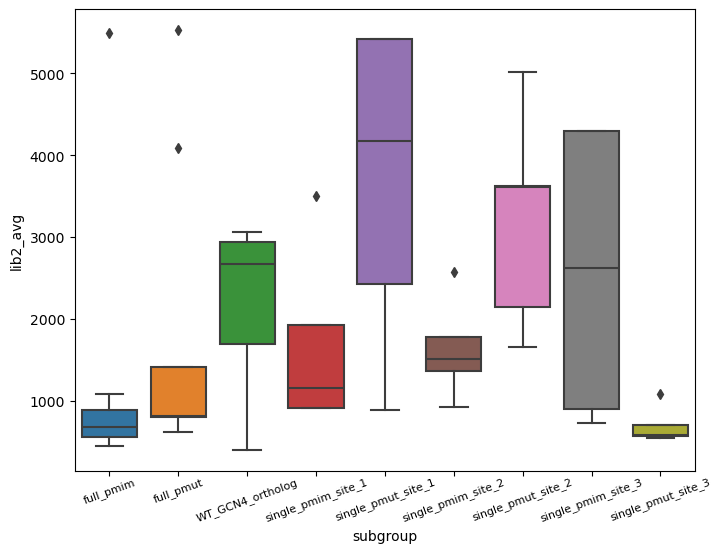

In [30]:
fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.boxplot(x = 'subgroup', y = 'lib2_avg', data = good_gcn4)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)

(70.15641191626355, 6000.0)

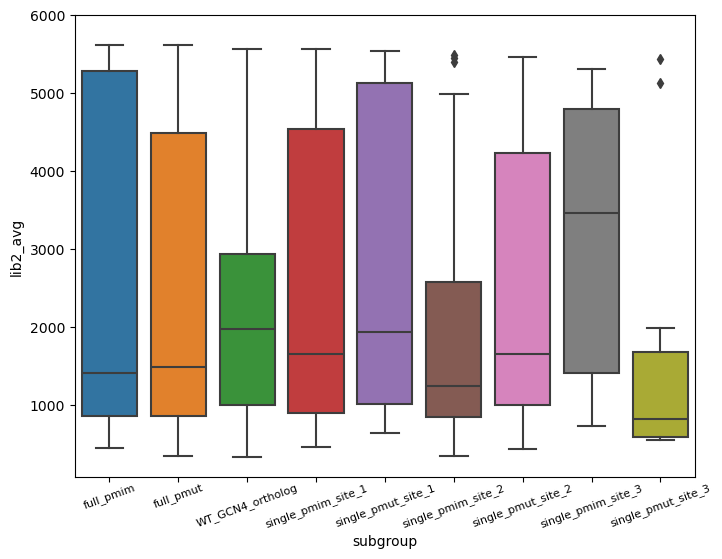

In [31]:
fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.boxplot(x = 'subgroup', y = 'lib2_avg', data = good_gcn4_all)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)
axes.set_ylim(top=6000)

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_d

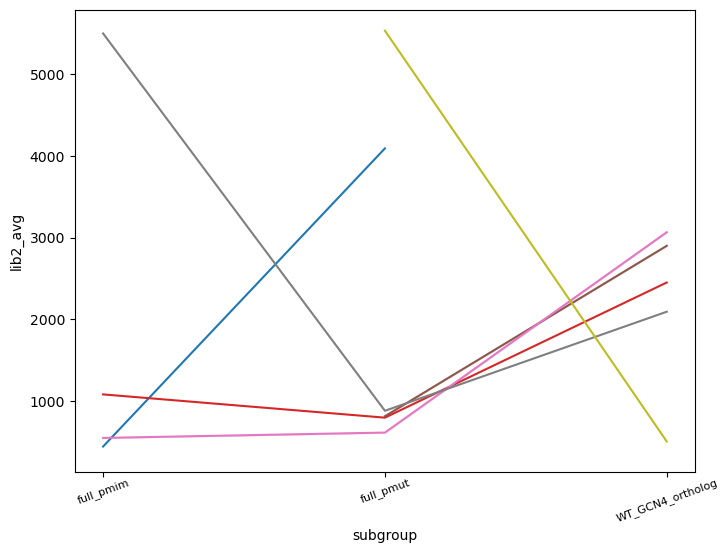

In [99]:
# top 50? Group of 50?
fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', data = good_gcn4[good_gcn4.subgroup.isin(['WT_GCN4_ortholog','full_pmim','full_pmut'])], legend = False)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)

In [33]:
good_gcn4_all.head()

,ortholog_tile_name,AAseq,tile,subgroup,lib2_avg,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,lib2_std,ArrayDNA
1,GCN4_CAAD40,STDSDPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,STDSdpMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,full_pmim,448.152950,472.106028,424.199871,615630.0,744008.0,33.874769,TCTACTGATTCTGATCCAATGTTTGAATATGAGAATTTGGAAGATA...
2,GCN4_CAAD40,STDSAPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,STDSapMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,full_pmut,4089.159189,3931.409814,4246.908563,41372.0,45165.0,223.091305,TCTACTGATTCTGCTCCAATGTTTGAATATGAGAATTTGGAAGATA...
5,War1_Cterm,PAPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,PapSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,full_pmut,1416.693992,1456.330732,1377.057252,33978.0,35679.0,56.054815,CCAGCTCCATCTTCTTCTGTTGATAATTTGAATGATTATTTGACTG...
6,GCN4alt,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,WT_GCN4_ortholog,397.265360,389.471551,405.059168,1262.0,1508.0,11.022110,GATGATGCTGTTGTTGAATCATTCTTCTCTTCTTCTACTGATTCTA...
9,Blastocladiomycota_jgi|Catan2|1506241|gm1.1155...,SSPPPASIATPSPPLAAAQHVPAADGQWLALFPHPSSIDF,SSPPPASIATPSPPLAAAQHVPAADGQWLALFPHPSSIDF,WT_GCN4_ortholog,2451.305221,2658.644500,2243.965942,6992.0,7290.0,293.222020,TCTTCTCCACCACCAGCTTCTATTGCTACTCCATCTCCACCATTGG...


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_d

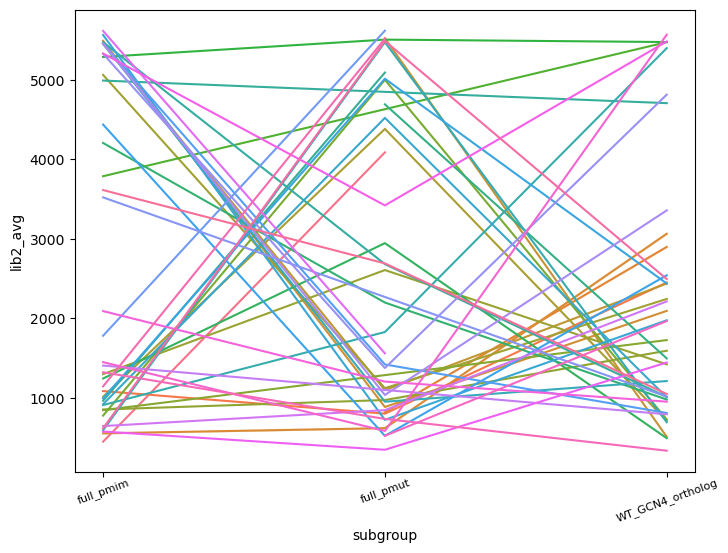

In [101]:
# all best
fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', data = good_gcn4_all[good_gcn4_all.subgroup.isin(['WT_GCN4_ortholog','full_pmim','full_pmut'])], legend = False)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)

## Further analysis - suggestions from max August 21

## Compare analyzed sorts (deep gDNA map vs shallow plasmid library map) , WT vs mutant scatters

In [26]:
activities_plasmidlib = pd.read_csv("Sog1_library2_activities_with_reads_ECspike.csv")
activities_gdna =  pd.read_csv(gdnamappath+"Sog1_library2_activities_with_reads_EC.csv")

In [27]:
activities_compare = activities_plasmidlib.merge(activities_gdna, on=['ArrayDNA', 'AAseq'], how='inner', suffixes=('_plib', '_gdna'))
activities_compare.head()

,ArrayDNA,Activity_S3_1_plib,Activity_S3_2_plib,reads_S3_1_plib,reads_S3_2_plib,AAseq,lib2_avg_plib,lib2_std_plib,Activity_S3_1_gdna,Activity_S3_2_gdna,reads_S3_1_gdna,reads_S3_2_gdna,lib2_avg_gdna,lib2_std_gdna
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,1079.074274,925.703811,610.0,643.0,KQRQNQNQGQQQPTWFQSGSQFILNSQQLVQALSLCQQLL,1002.389042,108.449295,363.558513,310.476753,39339.0,38479.0,337.017633,37.534473
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,1394.076068,1424.548173,44354.0,36001.0,KQRDNEDNGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1409.312120,21.547032,1352.816663,1376.225245,113311.0,110923.0,1364.520954,16.552367
2,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,283.663233,267.611412,5090.0,7330.0,KQIDIYKYDPWDLPRVSSVGEKEWYFFCMRGRKYRNSVRP,275.637323,11.350351,276.980750,259.929609,5064.0,7304.0,268.455180,12.056978
3,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,4076.691936,3163.539743,172.0,137.0,KQIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,3620.115839,645.696108,3705.254511,3990.921492,76741.0,66793.0,3848.088002,201.997060
4,AAACAAGAATTGATGGAAGAAGATGATGAGAAAGATAGAGATAATG...,1884.539399,1243.306954,99.0,106.0,KQELMEEDDEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1563.923176,453.419810,643.320070,646.990540,29209.0,34286.0,645.155305,2.595414


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr

# colors 
orange = (1.0, 0.41, 0.12)
alt_orange = (0.6, 0.21, 0.02)
burgundy = (0.6, 0.15, 0.15)
purple = (0.3, 0.16, 0.61)
teal = (0.26, 0.72, 0.73)
alt_teal = (0.16, 0.4, 0.4)
navy = (0.11, 0.16, 0.27)
gray = (0.49, 0.49, 0.49)
pink = (1.0, 0.08, 0.58)  # Define pink color

lin = LinearRegression()

def compare(X, Y, scores, color = navy, titles = None, x = 100, y = 15000, gridsize = 60, opt = '', line = True, title = None):
    plt.figure(1, dpi = 400)

    """
    X & Y: columns in a df
    scores: df with the columns you want to compare
    """
    
    scores = scores[[X,Y]].dropna(how='any')
    
    lin.fit(scores[[X]], scores[[Y]])
    sns.jointplot(data = scores, x = X, y = Y, color = color, kind = 'scatter')
    
    # Add the regression line if line=True
    if line:
        sns.regplot(data = scores, x = X, y = Y, scatter= False, ci = None, line_kws = {'color':navy, 'alpha':0.9}, truncate = True)
    
    # Add the y=x line in pink
    min_val = min(scores[[X, Y]].min())  # Find the minimum value for both X and Y
    max_val = max(scores[[X, Y]].max())  # Find the maximum value for both X and Y
    plt.plot([min_val, max_val], [min_val, max_val], color=pink, linestyle='--', label='y=x')

    cod = round(lin.score(scores[[X]], scores[[Y]]), 3)
    spearman = round(spearmanr(scores[[X]],scores[[Y]])[0], 3)
    
    if titles is not None:
        X = titles[0]
        Y = titles[1]
        plt.xlabel(titles[0])
        plt.ylabel(titles[1])
    
    plt.title(title, fontsize = 14, y = -0.17)
    plt.text(x,y, f"R^2 = {cod} \nSpearman: {spearman}\nNum shared tiles: {len(scores)}", fontsize = 12, bbox= {'color':'white','alpha':0.7})
    plt.legend()
    plt.tight_layout()
    
    if opt != '':
        plt.suptitle(opt, color='red', va='bottom')
    
    opt = opt+'_'
    # plt.savefig(f"./figures/{Y.replace(' ','_')}_v_{X.replace(' ','_')}{opt.replace(' ','_')}sog1_lib2_EC.svg")


### gDNA vs Plasmid map activities

/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 2560x1920 with 0 Axes>

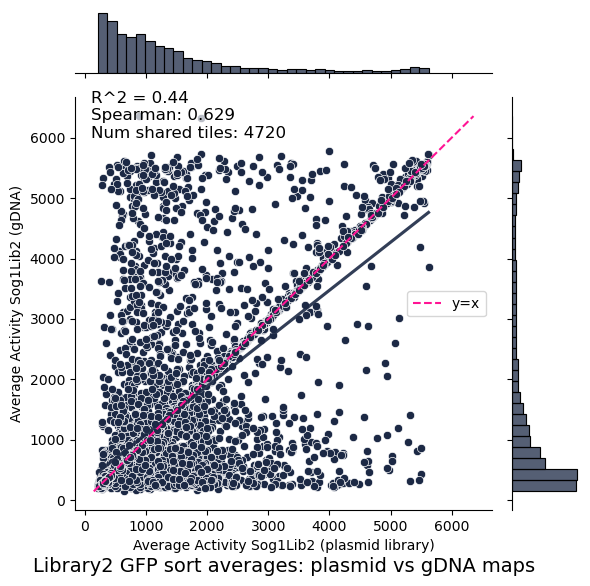

In [29]:
compare("lib2_avg_plib", "lib2_avg_gdna", activities_compare, y = 6000, titles = ["Average Activity Sog1Lib2 (plasmid library)", "Average Activity Sog1Lib2 (gDNA)"], 
       title = "Library2 GFP sort averages: plasmid vs gDNA maps")

## WT vs Mutant scatters

In [30]:
fromjordan = '/global/scratch/projects/fc_mvslab/data/sequencing/CZB_Feb2024/Sog1_Lib2_map/map_outputs/from_jordan/'
activities = pd.read_csv("Sog1_library2_activities_with_reads_ECspike.csv")
gcn4_tiles = pd.read_csv(fromjordan+"GCN4_phosphovariants_max_lists.csv", sep = ";")
gcn4_tiles['AAseq'] = [x.upper() for x in gcn4_tiles.tile]
# e2fa = e2fa_tiles.merge(activities, how = 'inner', on = 'AAseq')
# e2fa = e2fa[['tf_name','start','end','AAseq','tile','subgroup','lib2_avg','Activity_S3_1','Activity_S3_2','reads_S3_1', 'reads_S3_2','lib2_std','ArrayDNA']]

gcn4 = gcn4_tiles.merge(activities, how = 'inner', on = 'AAseq')
gcn4 = gcn4[['ortholog_tile_name','subgroup','lib2_avg',]]
# gcn4[['ortholog_tile_name', "tile", "subgroup", "Activity_S3_1", "Activity_S3_2",'reads_S3_1', 'reads_S3_2']][gcn4.ortholog_tile_name != "War1_Cterm"].iloc[0:6]
gcn4

,ortholog_tile_name,subgroup,lib2_avg
0,GCN4_CAAD40,WT_GCN4_ortholog,836.019736
1,GCN4_CAAD40,full_pmim,448.152950
2,GCN4_CAAD40,full_pmut,4089.159189
3,War1_Cterm,WT_GCN4_ortholog,1528.155941
4,War1_Cterm,full_pmim,973.120027
...,...,...,...
367,Cimm_XP_012214147.1_CoccidioidesImmitisRS_81,full_pmut,2691.868560
368,Cimm_XP_012214147.1_CoccidioidesImmitisRS_81,single_pmim_site_1,4534.842819
369,Cimm_XP_012214147.1_CoccidioidesImmitisRS_81,single_pmut_site_1,1050.116899
370,Cimm_XP_012214147.1_CoccidioidesImmitisRS_81,single_pmim_site_2,1235.784532


In [31]:
gcn4_values = gcn4.pivot_table(index='ortholog_tile_name', columns='subgroup', values='lib2_avg') #aggfunc='mean
gcn4_values.head()

subgroup,WT_GCN4_ortholog,full_pmim,full_pmut,single_pmim_site_1,single_pmim_site_2,single_pmim_site_3,single_pmut_site_1,single_pmut_site_2,single_pmut_site_3
ortholog_tile_name,,,,,,,,,
Agos_ADL012C_106,5485.522907,5333.885501,3421.959793,NaN,NaN,NaN,NaN,NaN,NaN
Blastocladiomycota_jgi|Catan2|1466814|fgenesh1_pg.199_#_9_61,712.155074,1012.699035,4384.591121,4403.201555,636.233499,1213.633107,643.296732,744.275910,823.384431
Blastocladiomycota_jgi|Catan2|1506241|gm1.11555_g_71,2451.305221,1084.830883,800.706411,3508.534686,926.196589,727.066450,2938.427288,3626.448481,1079.394536
Cimm_XP_012214147.1_CoccidioidesImmitisRS_81,1048.825426,3615.131855,2691.868560,4534.842819,1235.784532,NaN,1050.116899,1725.963931,NaN
Cmal_EMG49335.1_CandidaMaltosaXu316_76,1523.140618,1144.509777,5521.473299,NaN,NaN,NaN,NaN,NaN,NaN


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_175905/941745913.py:54: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 2560x1920 with 0 Axes>

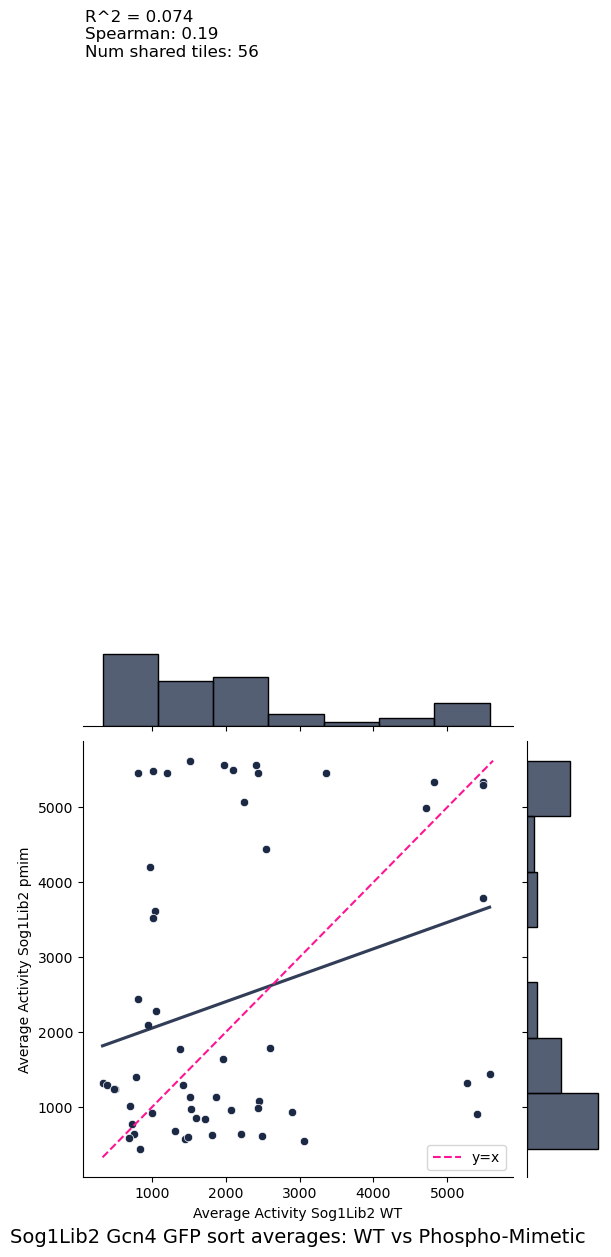

In [8]:
# next do scatters
compare("WT_GCN4_ortholog", "full_pmim", gcn4_values, titles = ["Average Activity Sog1Lib2 WT", "Average Activity Sog1Lib2 pmim"], 
       title = "Sog1Lib2 Gcn4 GFP sort averages: WT vs Phospho-Mimetic")

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_175905/941745913.py:54: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 2560x1920 with 0 Axes>

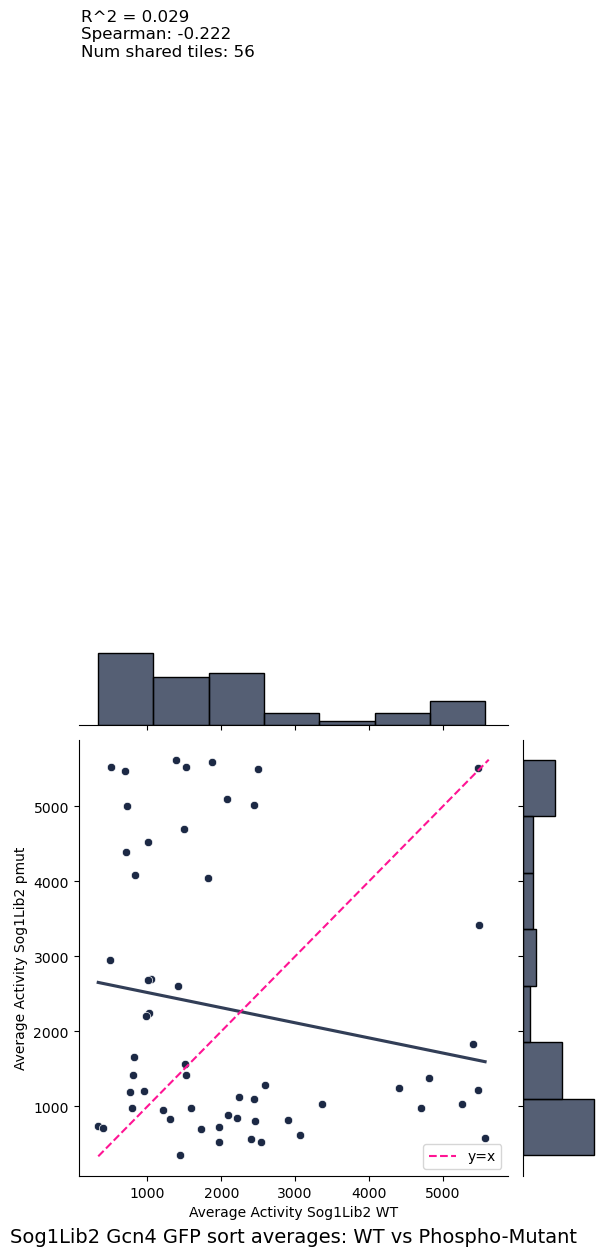

In [18]:
compare("WT_GCN4_ortholog", "full_pmut", gcn4_values,  titles = ["Average Activity Sog1Lib2 WT", "Average Activity Sog1Lib2 pmut"], 
       title = "Sog1Lib2 Gcn4 GFP sort averages: WT vs Phospho-Mutant")

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_175905/941745913.py:54: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 2560x1920 with 0 Axes>

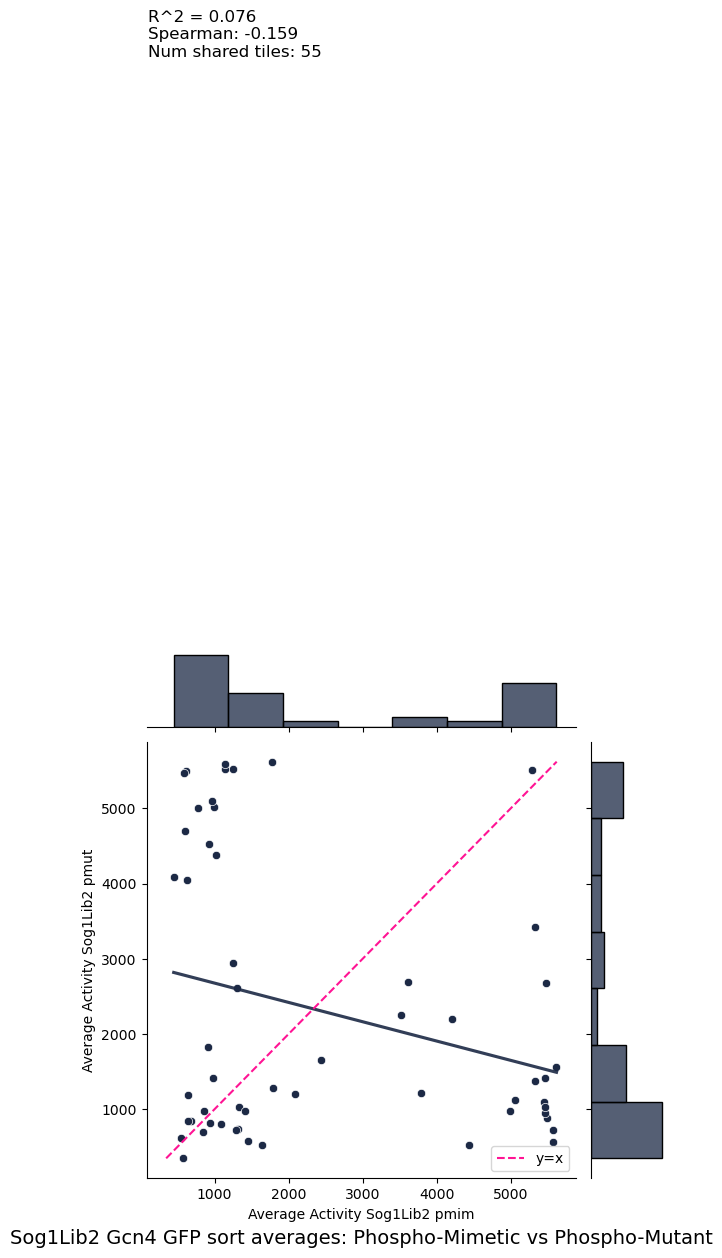

In [19]:
compare("full_pmim", "full_pmut", gcn4_values,  titles = ["Average Activity Sog1Lib2 pmim", "Average Activity Sog1Lib2 pmut"], 
       title = "Sog1Lib2 Gcn4 GFP sort averages: Phospho-Mimetic vs Phospho-Mutant")

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_175905/941745913.py:54: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 2560x1920 with 0 Axes>

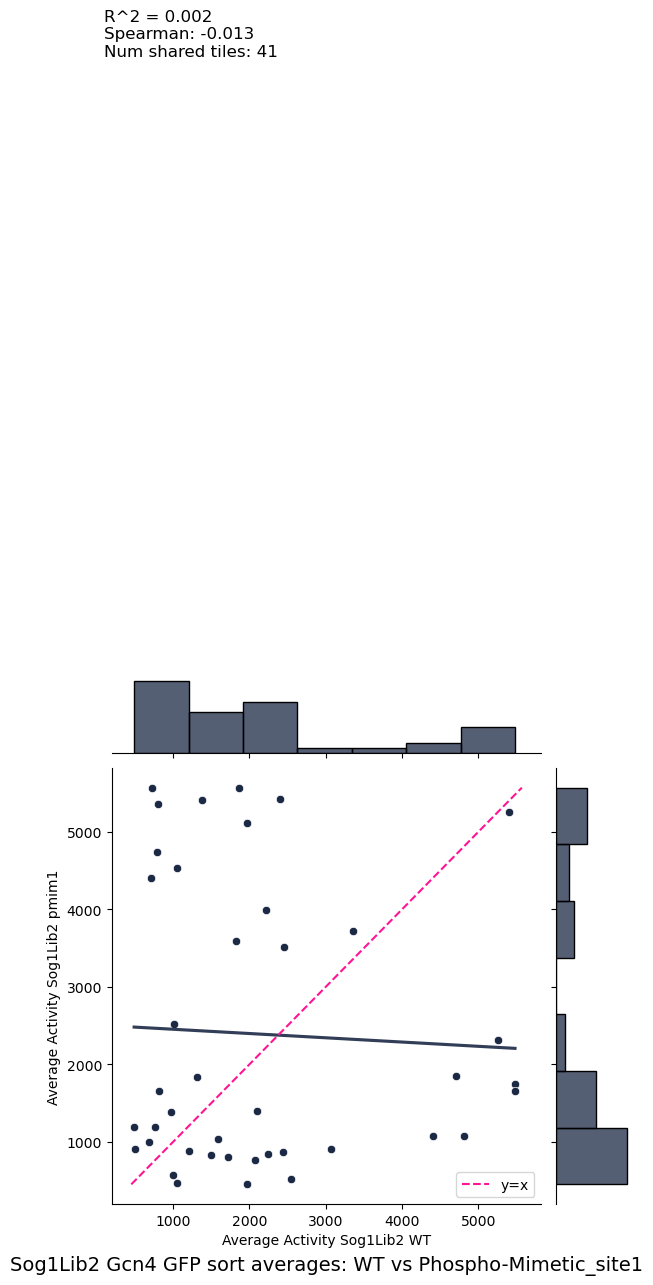

In [20]:
compare("WT_GCN4_ortholog", "single_pmim_site_1", gcn4_values,  titles = ["Average Activity Sog1Lib2 WT", "Average Activity Sog1Lib2 pmim1"], 
       title = "Sog1Lib2 Gcn4 GFP sort averages: WT vs Phospho-Mimetic_site1")

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_175905/941745913.py:54: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 2560x1920 with 0 Axes>

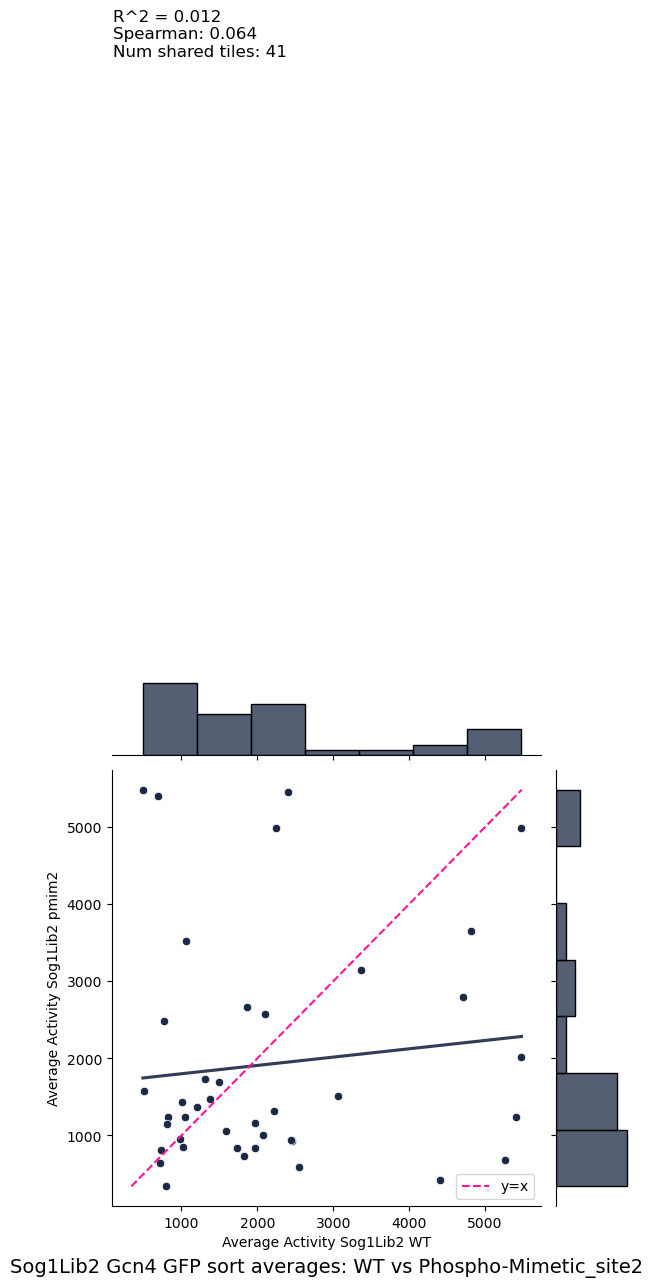

In [21]:
compare("WT_GCN4_ortholog", "single_pmim_site_2", gcn4_values,  titles = ["Average Activity Sog1Lib2 WT", "Average Activity Sog1Lib2 pmim2"], 
       title = "Sog1Lib2 Gcn4 GFP sort averages: WT vs Phospho-Mimetic_site2")

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_175905/941745913.py:54: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 2560x1920 with 0 Axes>

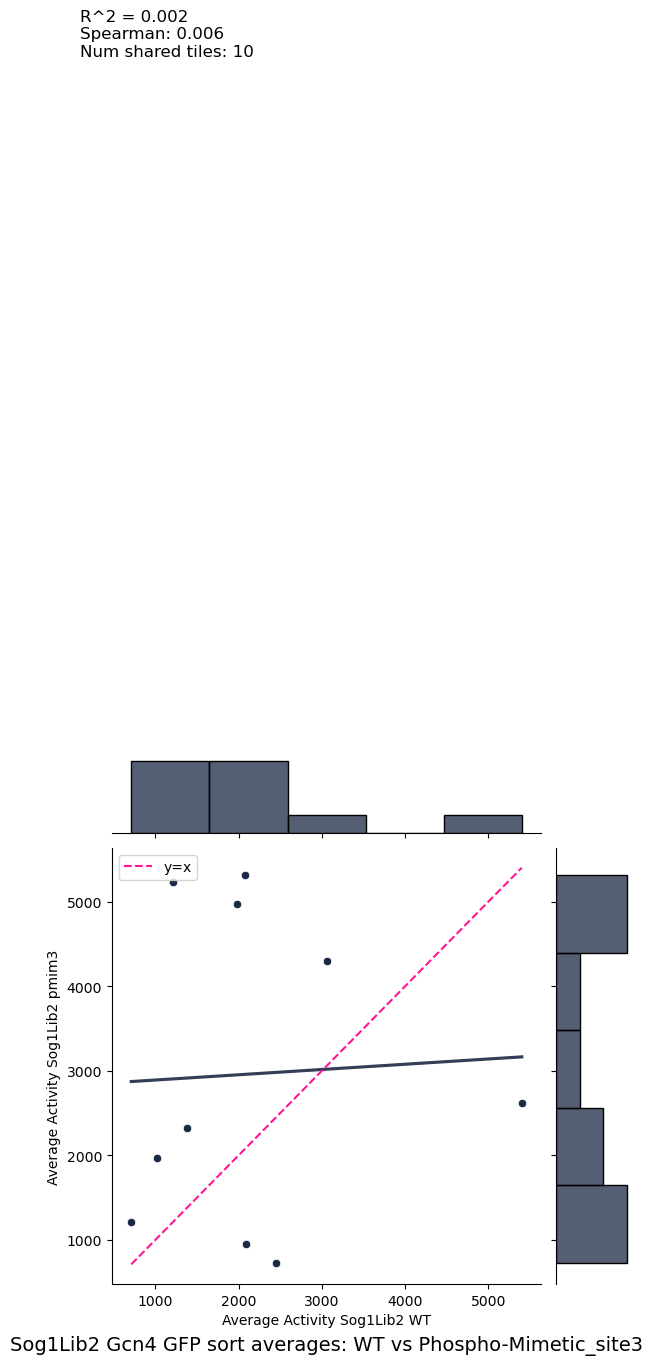

In [22]:
compare("WT_GCN4_ortholog", "single_pmim_site_3", gcn4_values,  titles = ["Average Activity Sog1Lib2 WT", "Average Activity Sog1Lib2 pmim3"], 
       title = "Sog1Lib2 Gcn4 GFP sort averages: WT vs Phospho-Mimetic_site3")

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_175905/941745913.py:54: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 2560x1920 with 0 Axes>

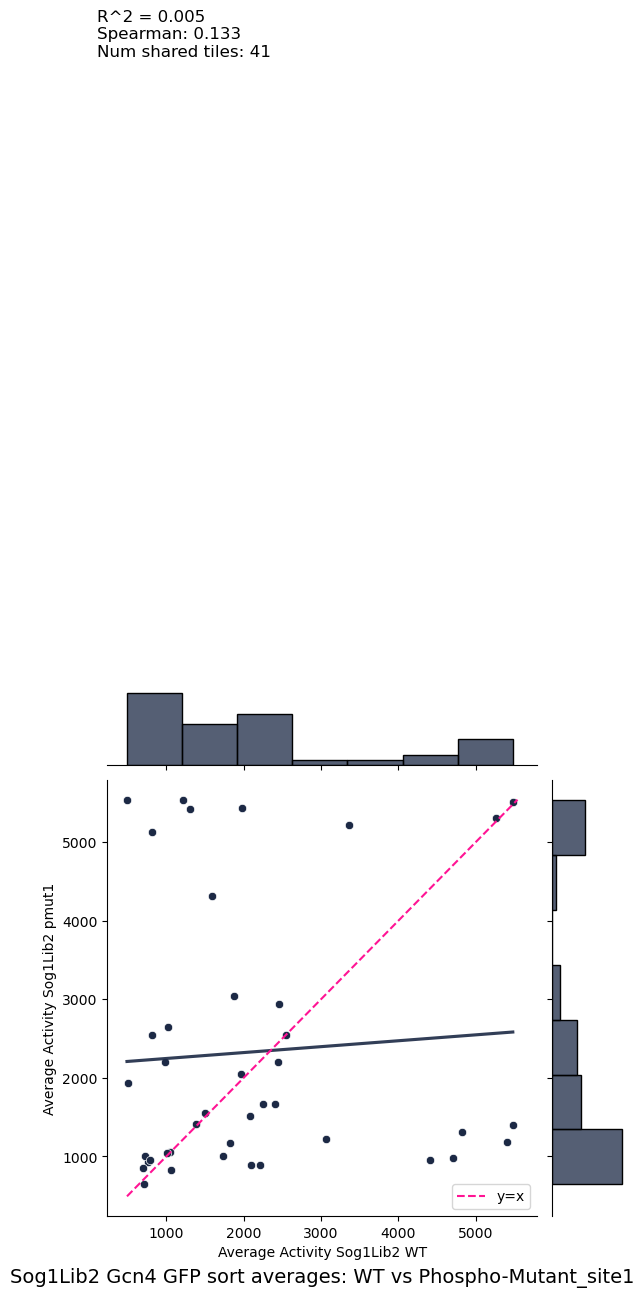

In [23]:
compare("WT_GCN4_ortholog", "single_pmut_site_1", gcn4_values,  titles = ["Average Activity Sog1Lib2 WT", "Average Activity Sog1Lib2 pmut1"], 
       title = "Sog1Lib2 Gcn4 GFP sort averages: WT vs Phospho-Mutant_site1")

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_175905/941745913.py:54: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 2560x1920 with 0 Axes>

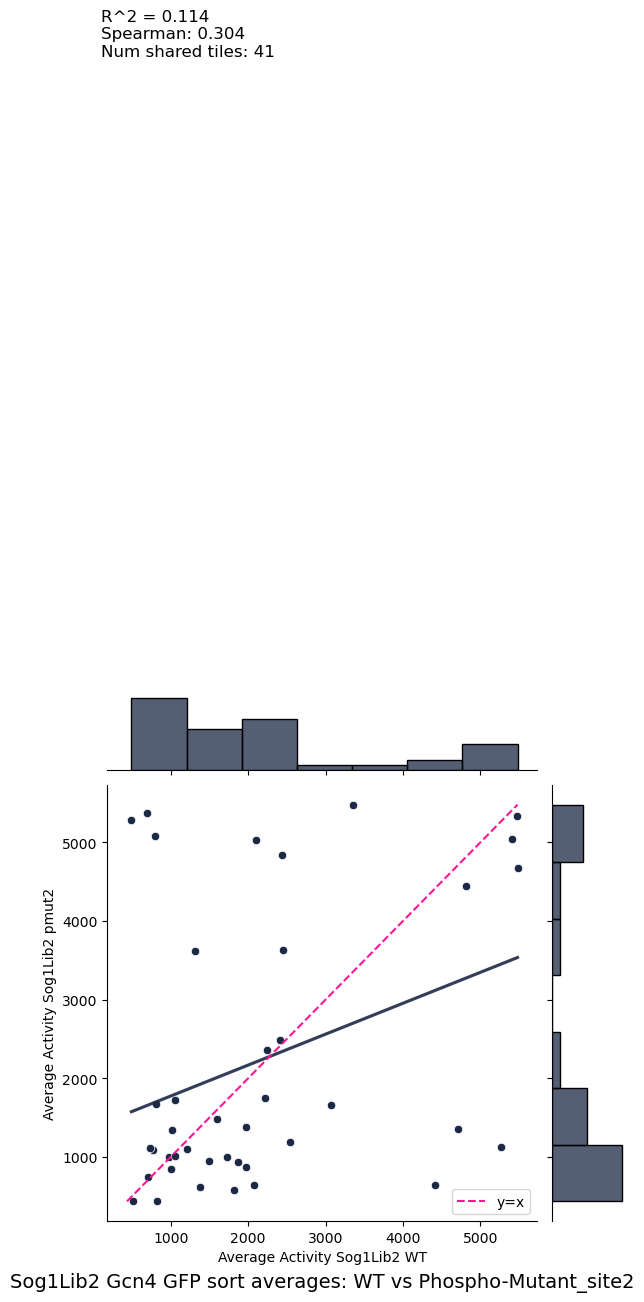

In [24]:
compare("WT_GCN4_ortholog", "single_pmut_site_2", gcn4_values,  titles = ["Average Activity Sog1Lib2 WT", "Average Activity Sog1Lib2 pmut2"], 
       title = "Sog1Lib2 Gcn4 GFP sort averages: WT vs Phospho-Mutant_site2")

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_175905/941745913.py:54: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 2560x1920 with 0 Axes>

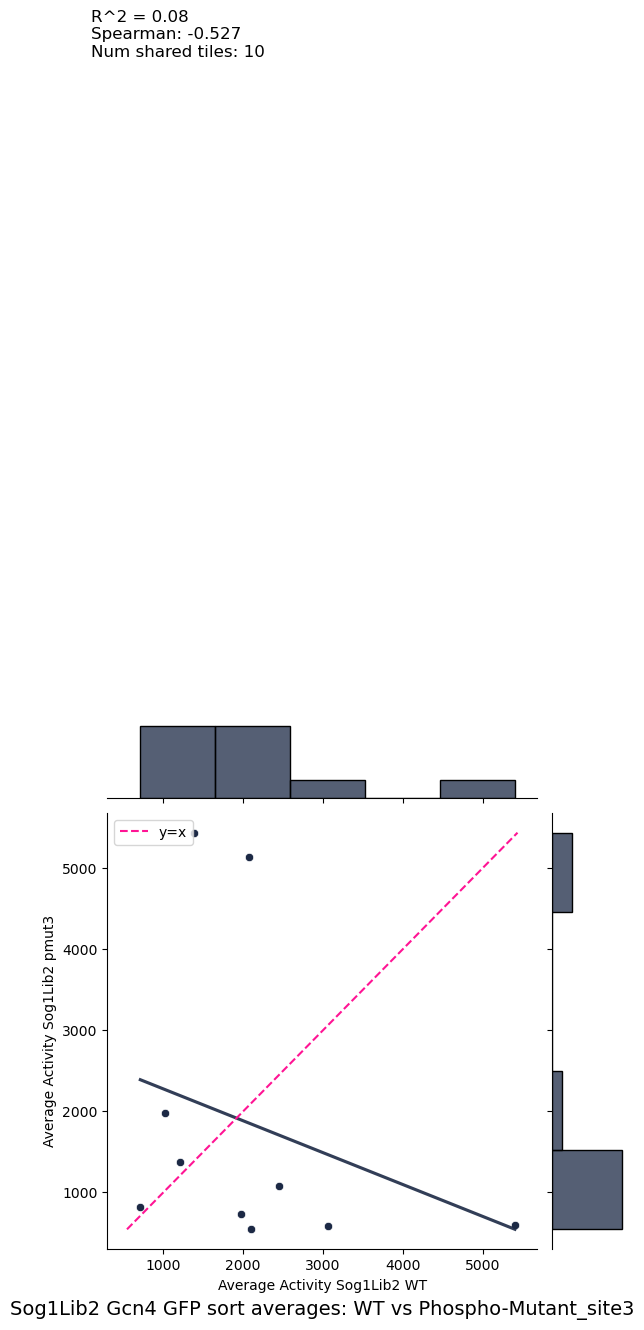

In [25]:
compare("WT_GCN4_ortholog", "single_pmut_site_3", gcn4_values,  titles = ["Average Activity Sog1Lib2 WT", "Average Activity Sog1Lib2 pmut3"], 
       title = "Sog1Lib2 Gcn4 GFP sort averages: WT vs Phospho-Mutant_site3")

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_175905/941745913.py:54: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 2560x1920 with 0 Axes>

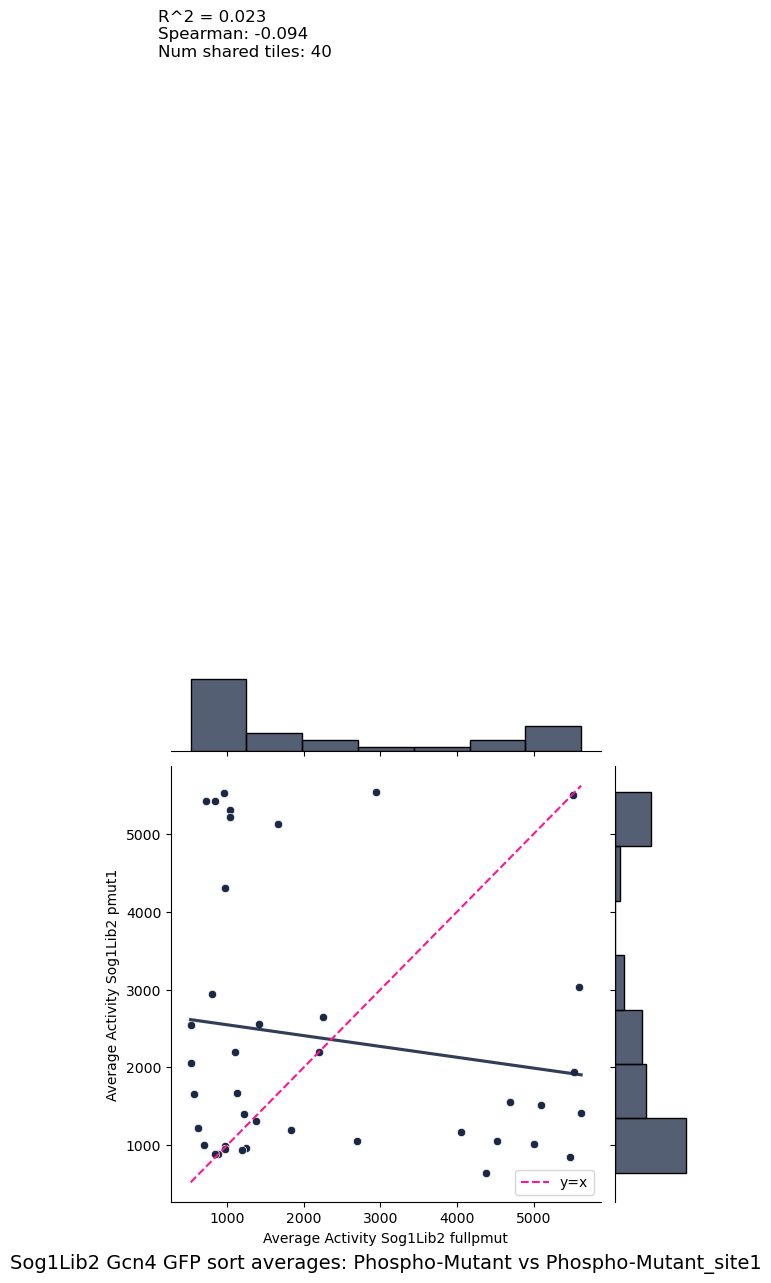

In [29]:
compare("full_pmut", "single_pmut_site_1", gcn4_values,  titles = ["Average Activity Sog1Lib2 fullpmut", "Average Activity Sog1Lib2 pmut1"], 
       title = "Sog1Lib2 Gcn4 GFP sort averages: Phospho-Mutant vs Phospho-Mutant_site1")

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_175905/941745913.py:54: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 2560x1920 with 0 Axes>

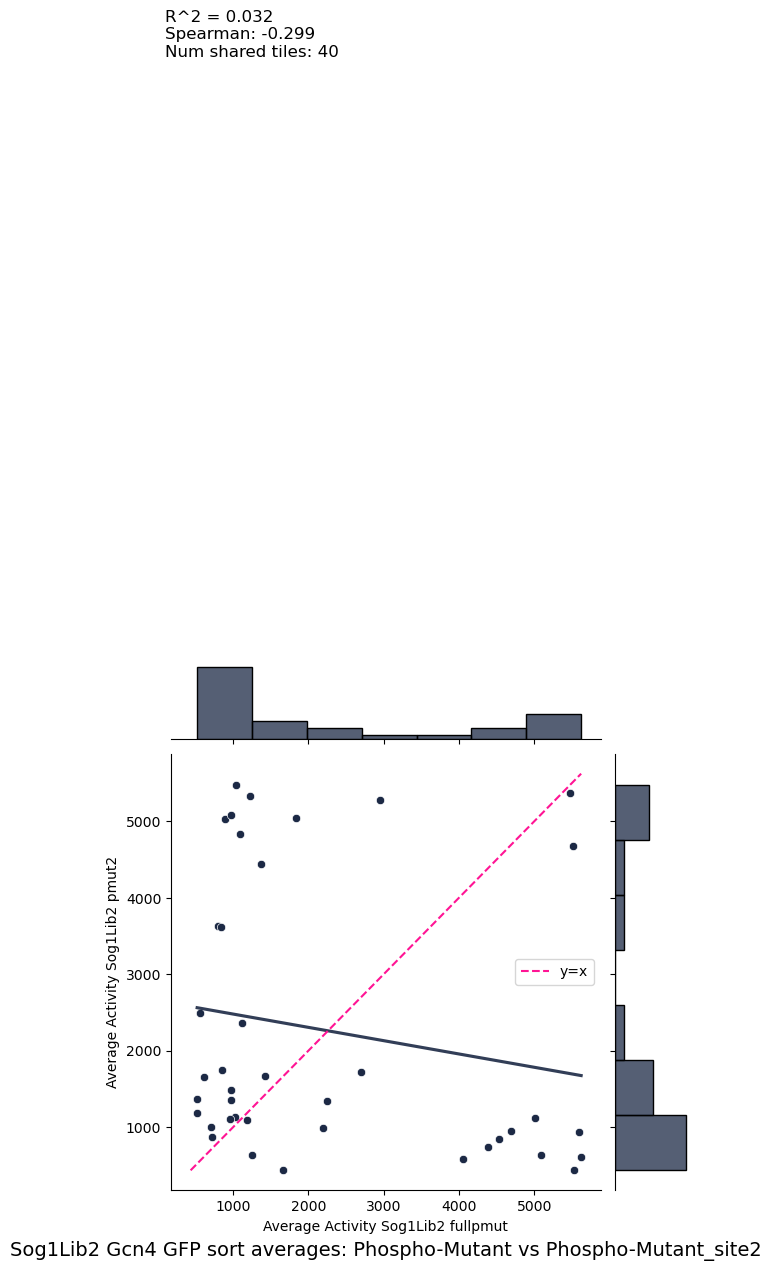

In [28]:
compare("full_pmut", "single_pmut_site_2", gcn4_values,  titles = ["Average Activity Sog1Lib2 fullpmut", "Average Activity Sog1Lib2 pmut2"], 
       title = "Sog1Lib2 Gcn4 GFP sort averages: Phospho-Mutant vs Phospho-Mutant_site2")

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_175905/941745913.py:54: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 2560x1920 with 0 Axes>

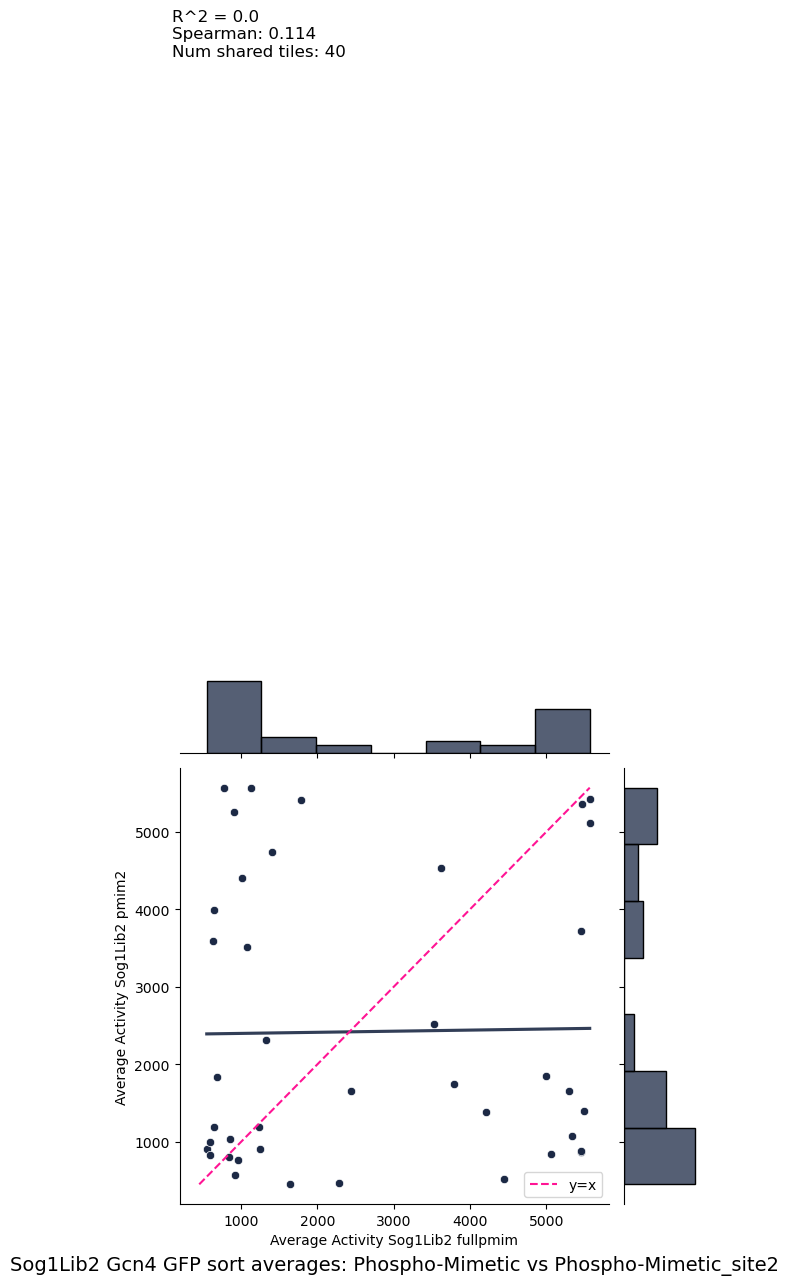

In [30]:
compare("full_pmim", "single_pmim_site_1", gcn4_values,  titles = ["Average Activity Sog1Lib2 fullpmim", "Average Activity Sog1Lib2 pmim2"], 
       title = "Sog1Lib2 Gcn4 GFP sort averages: Phospho-Mimetic vs Phospho-Mimetic_site2")

In [11]:
gcn4_values.head()

subgroup,WT_GCN4_ortholog,full_pmim,full_pmut,single_pmim_site_1,single_pmim_site_2,single_pmim_site_3,single_pmut_site_1,single_pmut_site_2,single_pmut_site_3
ortholog_tile_name,,,,,,,,,
Agos_ADL012C_106,5485.522907,5333.885501,3421.959793,NaN,NaN,NaN,NaN,NaN,NaN
Blastocladiomycota_jgi|Catan2|1466814|fgenesh1_pg.199_#_9_61,712.155074,1012.699035,4384.591121,4403.201555,636.233499,1213.633107,643.296732,744.275910,823.384431
Blastocladiomycota_jgi|Catan2|1506241|gm1.11555_g_71,2451.305221,1084.830883,800.706411,3508.534686,926.196589,727.066450,2938.427288,3626.448481,1079.394536
Cimm_XP_012214147.1_CoccidioidesImmitisRS_81,1048.825426,3615.131855,2691.868560,4534.842819,1235.784532,NaN,1050.116899,1725.963931,NaN
Cmal_EMG49335.1_CandidaMaltosaXu316_76,1523.140618,1144.509777,5521.473299,NaN,NaN,NaN,NaN,NaN,NaN


## Is the activity of Gcn4Alt high?

In [42]:
gcn4_values[gcn4_values['WT_GCN4_ortholog']<398]

subgroup,WT_GCN4_ortholog,full_pmim,full_pmut,single_pmim_site_1,single_pmim_site_2,single_pmim_site_3,single_pmut_site_1,single_pmut_site_2,single_pmut_site_3
ortholog_tile_name,,,,,,,,,
Ecym_4497_111,334.48688,1321.370913,734.324728,NaN,NaN,NaN,NaN,NaN,NaN
GCN4alt,397.26536,1295.819950,717.095391,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
gcn4_values_copy = gcn4_values.copy(deep=True)
gcn4_values_copy = gcn4_values_copy.reset_index()
# gcn4_values_copy[(gcn4_values_copy['ortholog_tile_name'] == 'GCN4alt') or (gcn4_values_copy['ortholog_tile_name'] == 'Agos_ADL012C_106') ] or(gcn4_values_copy['ortholog_tile_name'] == 'Ecym_4497_111'

<Axes: xlabel='ortholog_tile_name'>

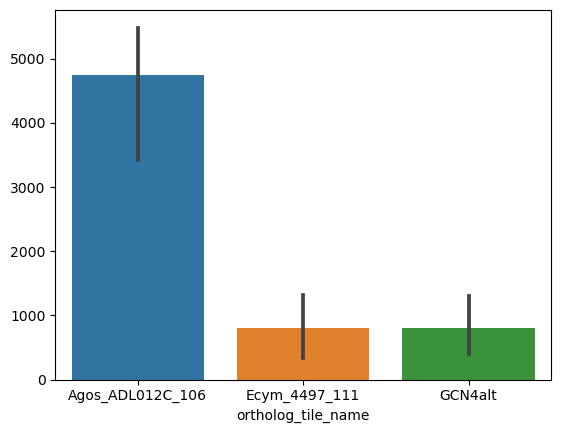

In [65]:
gcn4alttest = gcn4_values_copy[(gcn4_values_copy['ortholog_tile_name'].isin(['GCN4alt', 'Agos_ADL012C_106', 'Ecym_4497_111']))].reset_index()
gcn4alttest = gcn4alttest[['WT_GCN4_ortholog','full_pmim','full_pmut','ortholog_tile_name']].set_index('ortholog_tile_name')
gcn4alttest = gcn4alttest.T
sns.barplot(gcn4alttest)


KeyError: 'ortholog_tile_name'

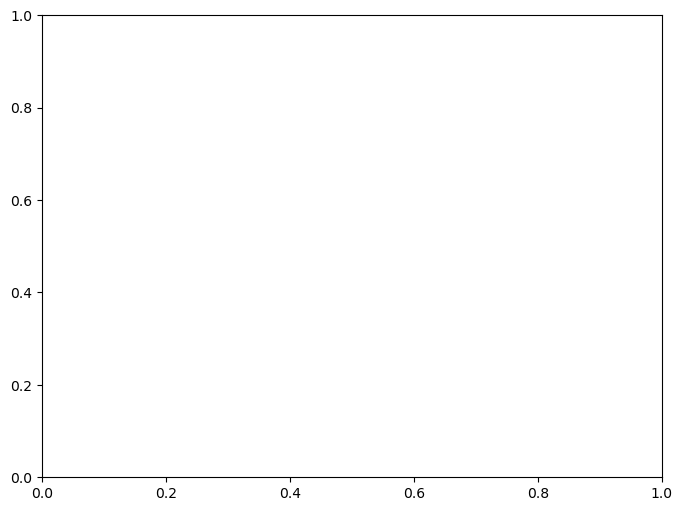

In [68]:
# all best
fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',
             # hue = 'ortholog_tile_name', 
             data = gcn4alttest[gcn4alttest[gcn4alttest['ortholog_tile_name'].isin(['GCN4alt'])]], legend = False)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)

## Follow up on phosphomutants - Max's requested analysis September 27 (analysis performed October 11, 2024)

In [32]:
gcn4_values = good_gcn4_all.pivot_table(index='ortholog_tile_name', columns='subgroup', values='lib2_avg') #aggfunc='mean
gcn4_values.head()

subgroup,WT_GCN4_ortholog,full_pmim,full_pmut,single_pmim_site_1,single_pmim_site_2,single_pmim_site_3,single_pmut_site_1,single_pmut_site_2,single_pmut_site_3
ortholog_tile_name,,,,,,,,,
Agos_ADL012C_106,5485.522907,5333.885501,3421.959793,NaN,NaN,NaN,NaN,NaN,NaN
Blastocladiomycota_jgi|Catan2|1466814|fgenesh1_pg.199_#_9_61,712.155074,1012.699035,4384.591121,4403.201555,636.233499,1213.633107,643.296732,744.275910,823.384431
Blastocladiomycota_jgi|Catan2|1506241|gm1.11555_g_71,2451.305221,1084.830883,800.706411,3508.534686,926.196589,727.066450,2938.427288,3626.448481,1079.394536
Cimm_XP_012214147.1_CoccidioidesImmitisRS_81,1048.825426,3615.131855,2691.868560,4534.842819,1235.784532,NaN,1050.116899,1725.963931,NaN
Cmal_EMG49335.1_CandidaMaltosaXu316_76,NaN,1144.509777,5521.473299,NaN,NaN,NaN,NaN,NaN,NaN


## For tiles with all three do line graph


In [33]:
gcn4_values_fulmut = gcn4_values.copy(deep=True)
gcn4_values_fulmut = gcn4_values_fulmut.reset_index()
gcn4_values_fulmut = gcn4_values_fulmut[['full_pmim','WT_GCN4_ortholog','full_pmut','ortholog_tile_name']]

In [34]:
gcn4_values_fulmut = gcn4_values_fulmut[~gcn4_values_fulmut.isna().any(axis=1)]

In [35]:
gcn4_values_fulmut

subgroup,full_pmim,WT_GCN4_ortholog,full_pmut,ortholog_tile_name
0,5333.885501,5485.522907,3421.959793,Agos_ADL012C_106
1,1012.699035,712.155074,4384.591121,Blastocladiomycota_jgi|Catan2|1466814|fgenesh1...
2,1084.830883,2451.305221,800.706411,Blastocladiomycota_jgi|Catan2|1506241|gm1.1155...
3,3615.131855,1048.825426,2691.868560,Cimm_XP_012214147.1_CoccidioidesImmitisRS_81
5,616.484692,2494.628446,5491.348064,Cort_emb_CCG25633.1_CandidaOrthopsilosis_81
6,2091.605758,951.627683,1204.411117,Cpar_CPAG02317_86
11,4439.520411,2542.444474,521.324174,Dothideomycetes_jgi|Settu3|1307314|e_gw1.7.816...
12,553.345392,3065.411765,618.511313,Dothideomycetes_jgi|Ternu1|257952|gw1.42.157.1_71
14,1321.370913,334.486880,734.324728,Ecym_4497_111
15,5454.822129,2438.481565,1096.720151,Eurotiomycetes_jgi|Aspsublat1|34395|CE34394_10...


In [36]:
gcn4_values_fulmut_melt = pd.melt(gcn4_values_fulmut, id_vars='ortholog_tile_name', value_name='lib2_avg' )

In [37]:
print(gcn4_values_fulmut_melt.head())

                                  ortholog_tile_name   subgroup     lib2_avg
0                                   Agos_ADL012C_106  full_pmim  5333.885501
1  Blastocladiomycota_jgi|Catan2|1466814|fgenesh1...  full_pmim  1012.699035
2  Blastocladiomycota_jgi|Catan2|1506241|gm1.1155...  full_pmim  1084.830883
3       Cimm_XP_012214147.1_CoccidioidesImmitisRS_81  full_pmim  3615.131855
4        Cort_emb_CCG25633.1_CandidaOrthopsilosis_81  full_pmim   616.484692


/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: Fu

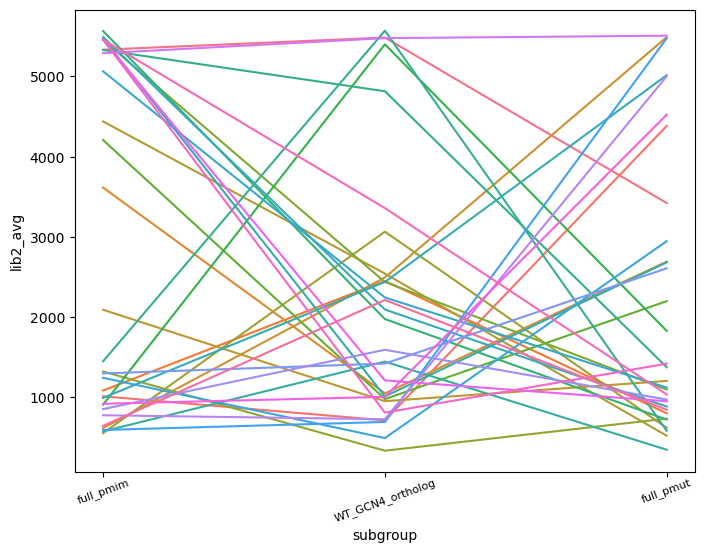

In [38]:
# all best
fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', data = gcn4_values_fulmut_melt, legend = False)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)

In [39]:
gcn4_values_fulmut.head()

subgroup,full_pmim,WT_GCN4_ortholog,full_pmut,ortholog_tile_name
0,5333.885501,5485.522907,3421.959793,Agos_ADL012C_106
1,1012.699035,712.155074,4384.591121,Blastocladiomycota_jgi|Catan2|1466814|fgenesh1...
2,1084.830883,2451.305221,800.706411,Blastocladiomycota_jgi|Catan2|1506241|gm1.1155...
3,3615.131855,1048.825426,2691.868560,Cimm_XP_012214147.1_CoccidioidesImmitisRS_81
5,616.484692,2494.628446,5491.348064,Cort_emb_CCG25633.1_CandidaOrthopsilosis_81


In [40]:
# value differences
gcn4_values_fulmut['pmim-WT'] = gcn4_values_fulmut['full_pmim'] - gcn4_values_fulmut['WT_GCN4_ortholog']
gcn4_values_fulmut['pmut-WT'] = gcn4_values_fulmut['full_pmut'] - gcn4_values_fulmut['WT_GCN4_ortholog']

/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: Fu

Text(0.5, 1.0, 'Phosphomutant increases activity from low to high')

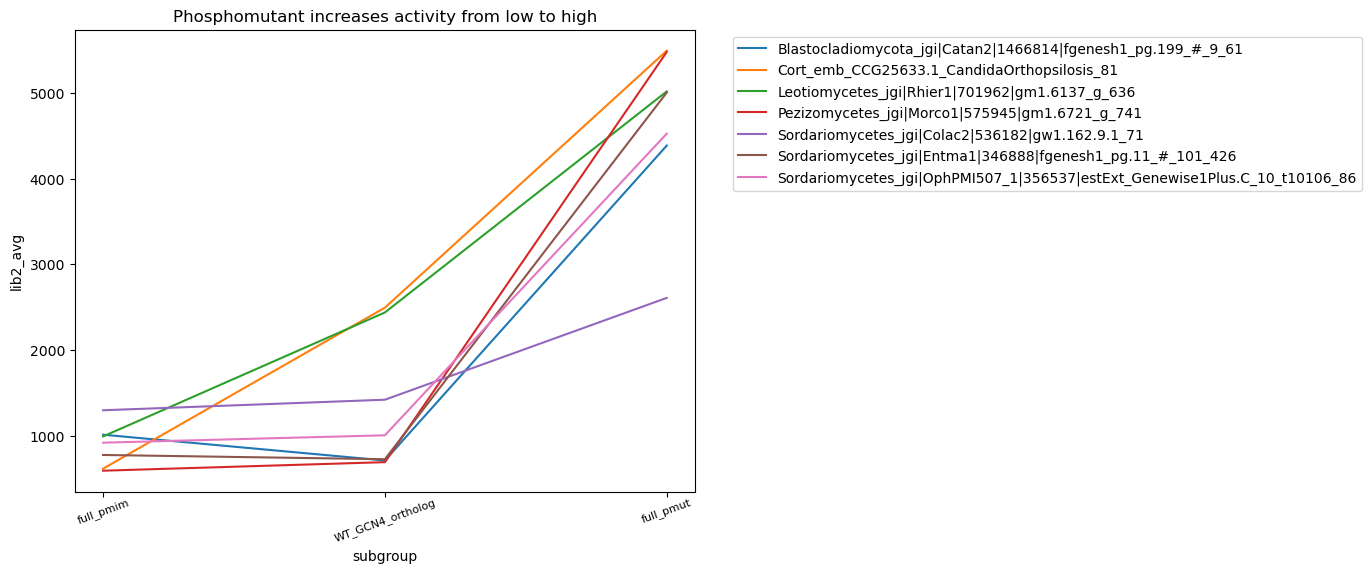

In [41]:
# Phosphomutant increases activity
mimlow_muthigh = gcn4_values_fulmut[(gcn4_values_fulmut['pmim-WT']<500)&(gcn4_values_fulmut['pmut-WT']>1000)]

fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', 
             data = pd.melt(mimlow_muthigh, id_vars='ortholog_tile_name', 
                            value_vars=['full_pmim','WT_GCN4_ortholog','full_pmut'], value_name='lib2_avg' ), 
             legend = True)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Phosphomutant increases activity from low to high')

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_d

Text(0.5, 1.0, 'Phosphomimetic increases activity')

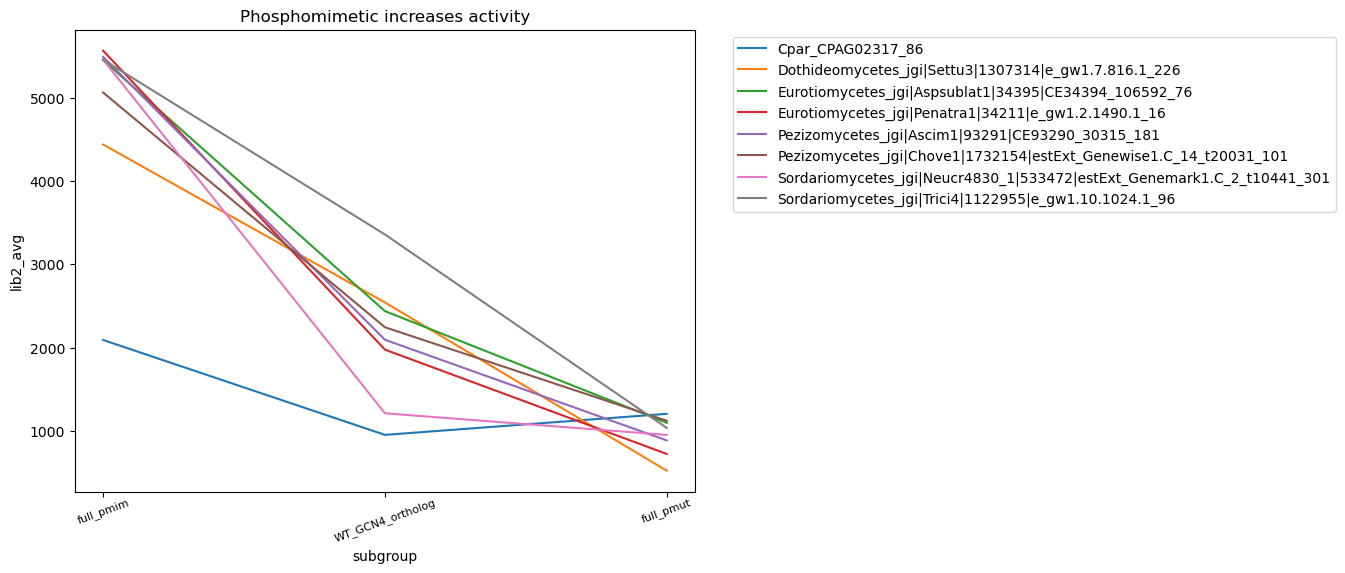

In [192]:
# Phosphomimetic increases activity
mimhigh_mutlow = gcn4_values_fulmut[(gcn4_values_fulmut['pmim-WT']>1000)&(gcn4_values_fulmut['pmut-WT']<500)]

fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', 
             data = pd.melt(mimhigh_mutlow, id_vars='ortholog_tile_name', 
                            value_vars=['full_pmim','WT_GCN4_ortholog','full_pmut'], value_name='lib2_avg' ), 
             legend = True)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Phosphomimetic increases activity')

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_d

Text(0.5, 1.0, 'WT has highest activity')

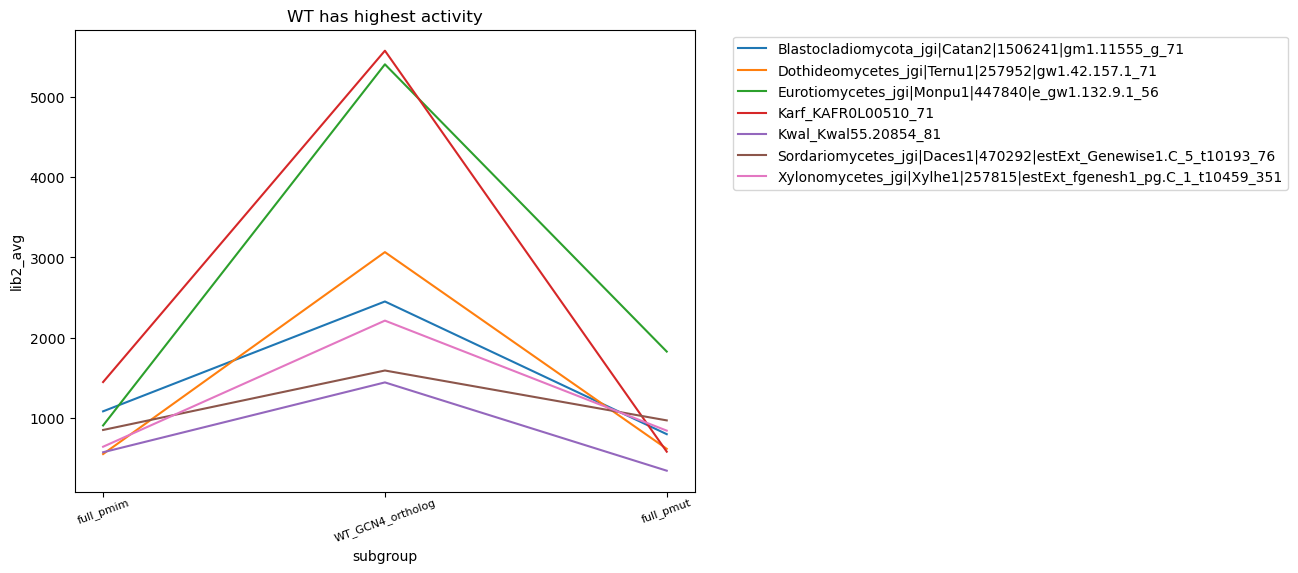

In [193]:
# Both mutant and mimetic decrease activity
WThigh_plow = gcn4_values_fulmut[(gcn4_values_fulmut['pmim-WT']<-500)&(gcn4_values_fulmut['pmut-WT']<-500)]

fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', 
             data = pd.melt(WThigh_plow, id_vars='ortholog_tile_name', 
                            value_vars=['full_pmim','WT_GCN4_ortholog','full_pmut'], value_name='lib2_avg' ), 
             legend = True)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('WT has highest activity')

/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: Fu

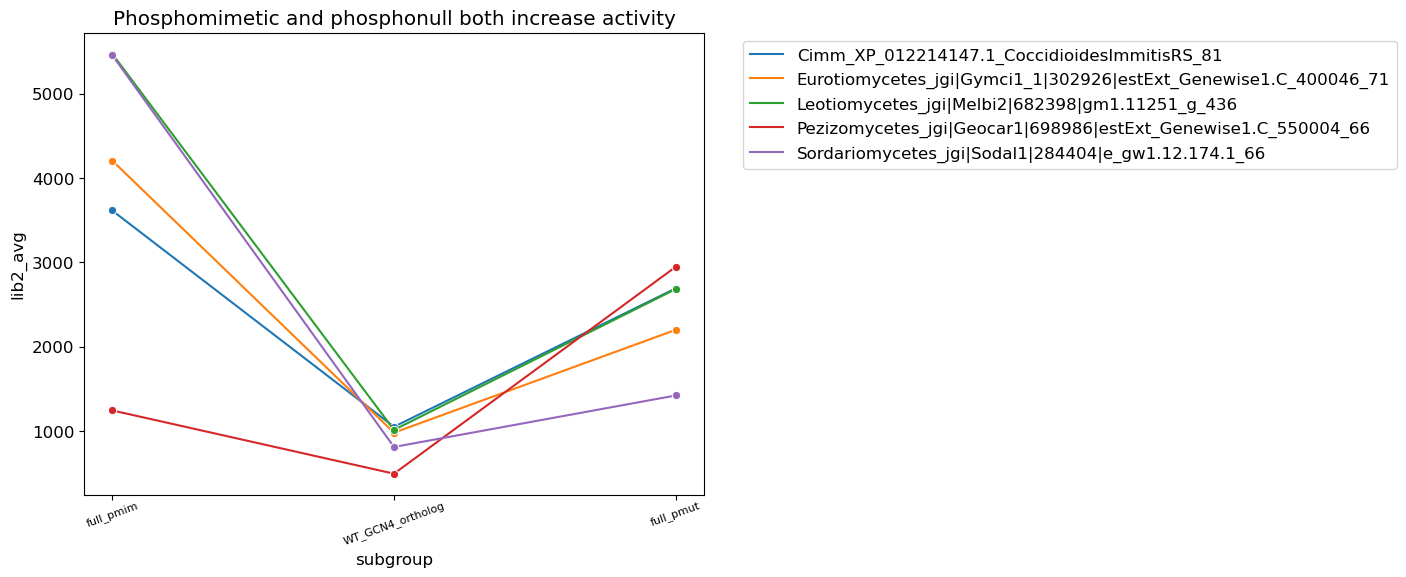

In [55]:
# Both mutant and mimetic increase activity
WTlow_phigh = gcn4_values_fulmut[(gcn4_values_fulmut['pmim-WT']>500)&(gcn4_values_fulmut['pmut-WT']>500)]

fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', 
             data = pd.melt(WTlow_phigh, id_vars='ortholog_tile_name', 
                            value_vars=['full_pmim','WT_GCN4_ortholog','full_pmut'], value_name='lib2_avg' ), 
             legend = True,
            marker='o',  # Add circular markers (you can change this to 's' for squares)
            markersize=6   # Adjust marker size
            )
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Phosphomimetic and phosphonull both increase activity')

# Save the figure with the correct DPI and preserve colored lines in the legend
plt.savefig('Phosphomimetic+phosphonull_increase_activity.svg', bbox_inches='tight', dpi=300)
plt.show()

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_d

Text(0.5, 1.0, 'Phosphomutant has lowest activity')

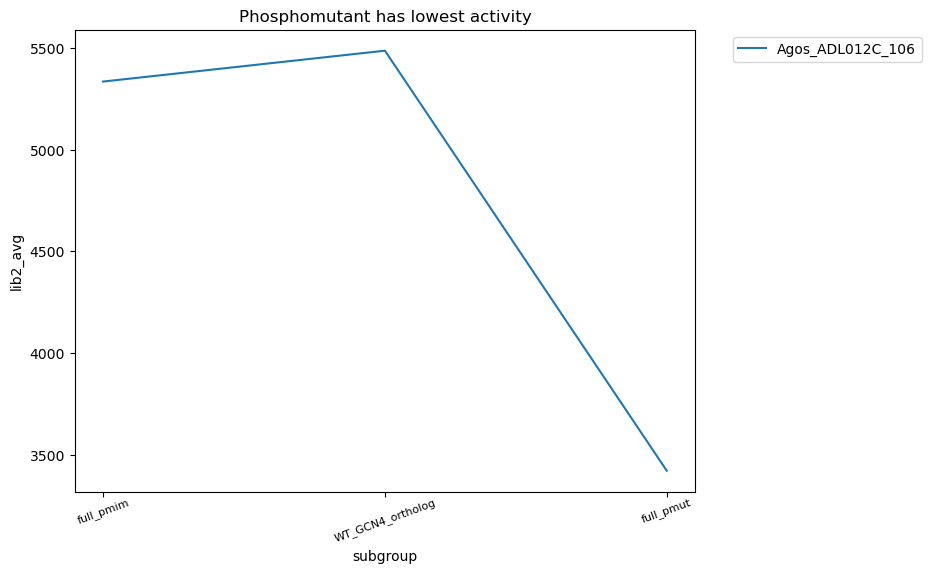

In [195]:
# pmutamnt decreases activity
pmutlow = gcn4_values_fulmut[(abs(gcn4_values_fulmut['pmim-WT'])<500)&((gcn4_values_fulmut['pmut-WT'])<-500)]

fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', 
             data = pd.melt(pmutlow, id_vars='ortholog_tile_name', 
                            value_vars=['full_pmim','WT_GCN4_ortholog','full_pmut'], value_name='lib2_avg' ), 
             legend = True)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Phosphomutant has lowest activity')

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_d

Text(0.5, 1.0, 'Phosphomimetic has lowest activity')

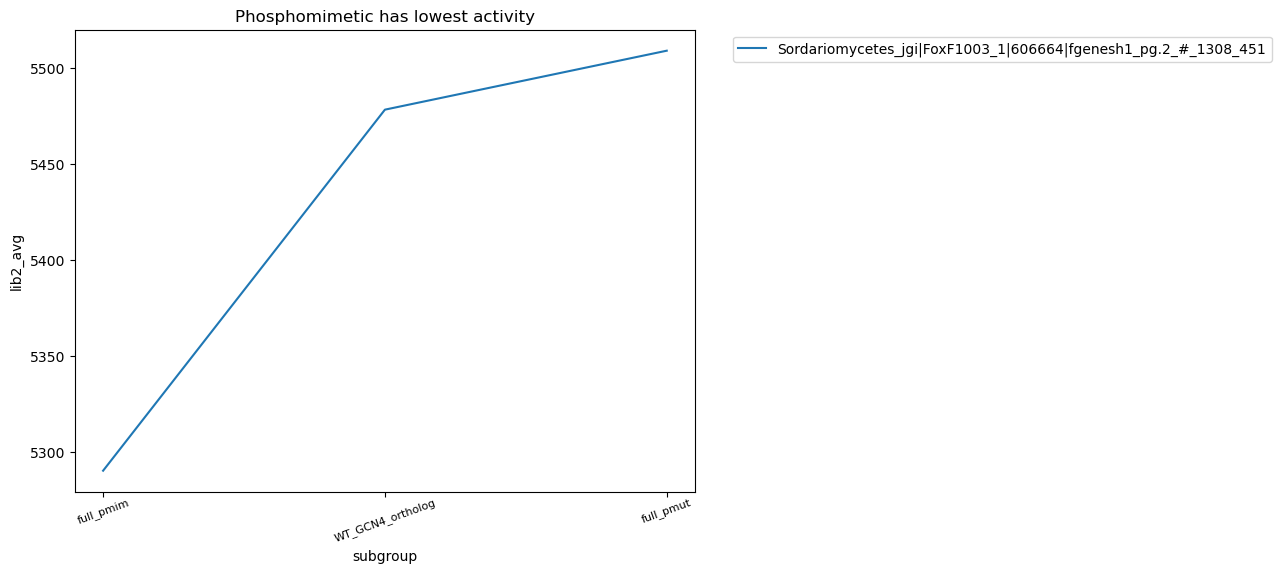

In [200]:
# pmim decreases activity
pmimlow = gcn4_values_fulmut[(gcn4_values_fulmut['pmim-WT']<0)&(abs(gcn4_values_fulmut['pmut-WT'])<500)]

fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', 
             data = pd.melt(pmimlow, id_vars='ortholog_tile_name', 
                            value_vars=['full_pmim','WT_GCN4_ortholog','full_pmut'], value_name='lib2_avg' ), 
             legend = True)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Phosphomimetic has lowest activity')

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_d

Text(0.5, 1.0, 'Minimal activity changes')

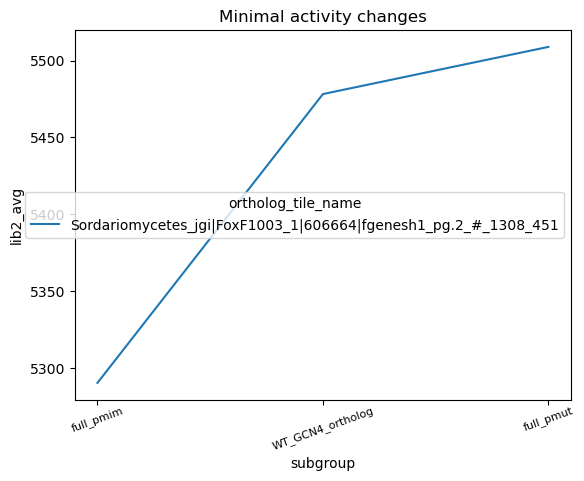

In [197]:
nochange = gcn4_values_fulmut[(abs(gcn4_values_fulmut['pmim-WT'])<500)&(abs(gcn4_values_fulmut['pmut-WT'])<500)]
sns.lineplot(x='subgroup', y='lib2_avg', hue='ortholog_tile_name',
             data=pd.melt(nochange, id_vars='ortholog_tile_name',
                          value_vars=['full_pmim', 'WT_GCN4_ortholog', 'full_pmut'], value_name='lib2_avg'),
         )
plt.tick_params('x', labelsize=8, bottom=True, labelrotation=20, pad=0)
plt.title('Minimal activity changes') 

In [51]:
matplotlib.rc('font', family='sans-serif') 
matplotlib.rc('font', serif='Helvetica Neue') 
matplotlib.rc('text', usetex='false') 
matplotlib.rcParams.update({'font.size': 12})

/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: Fu

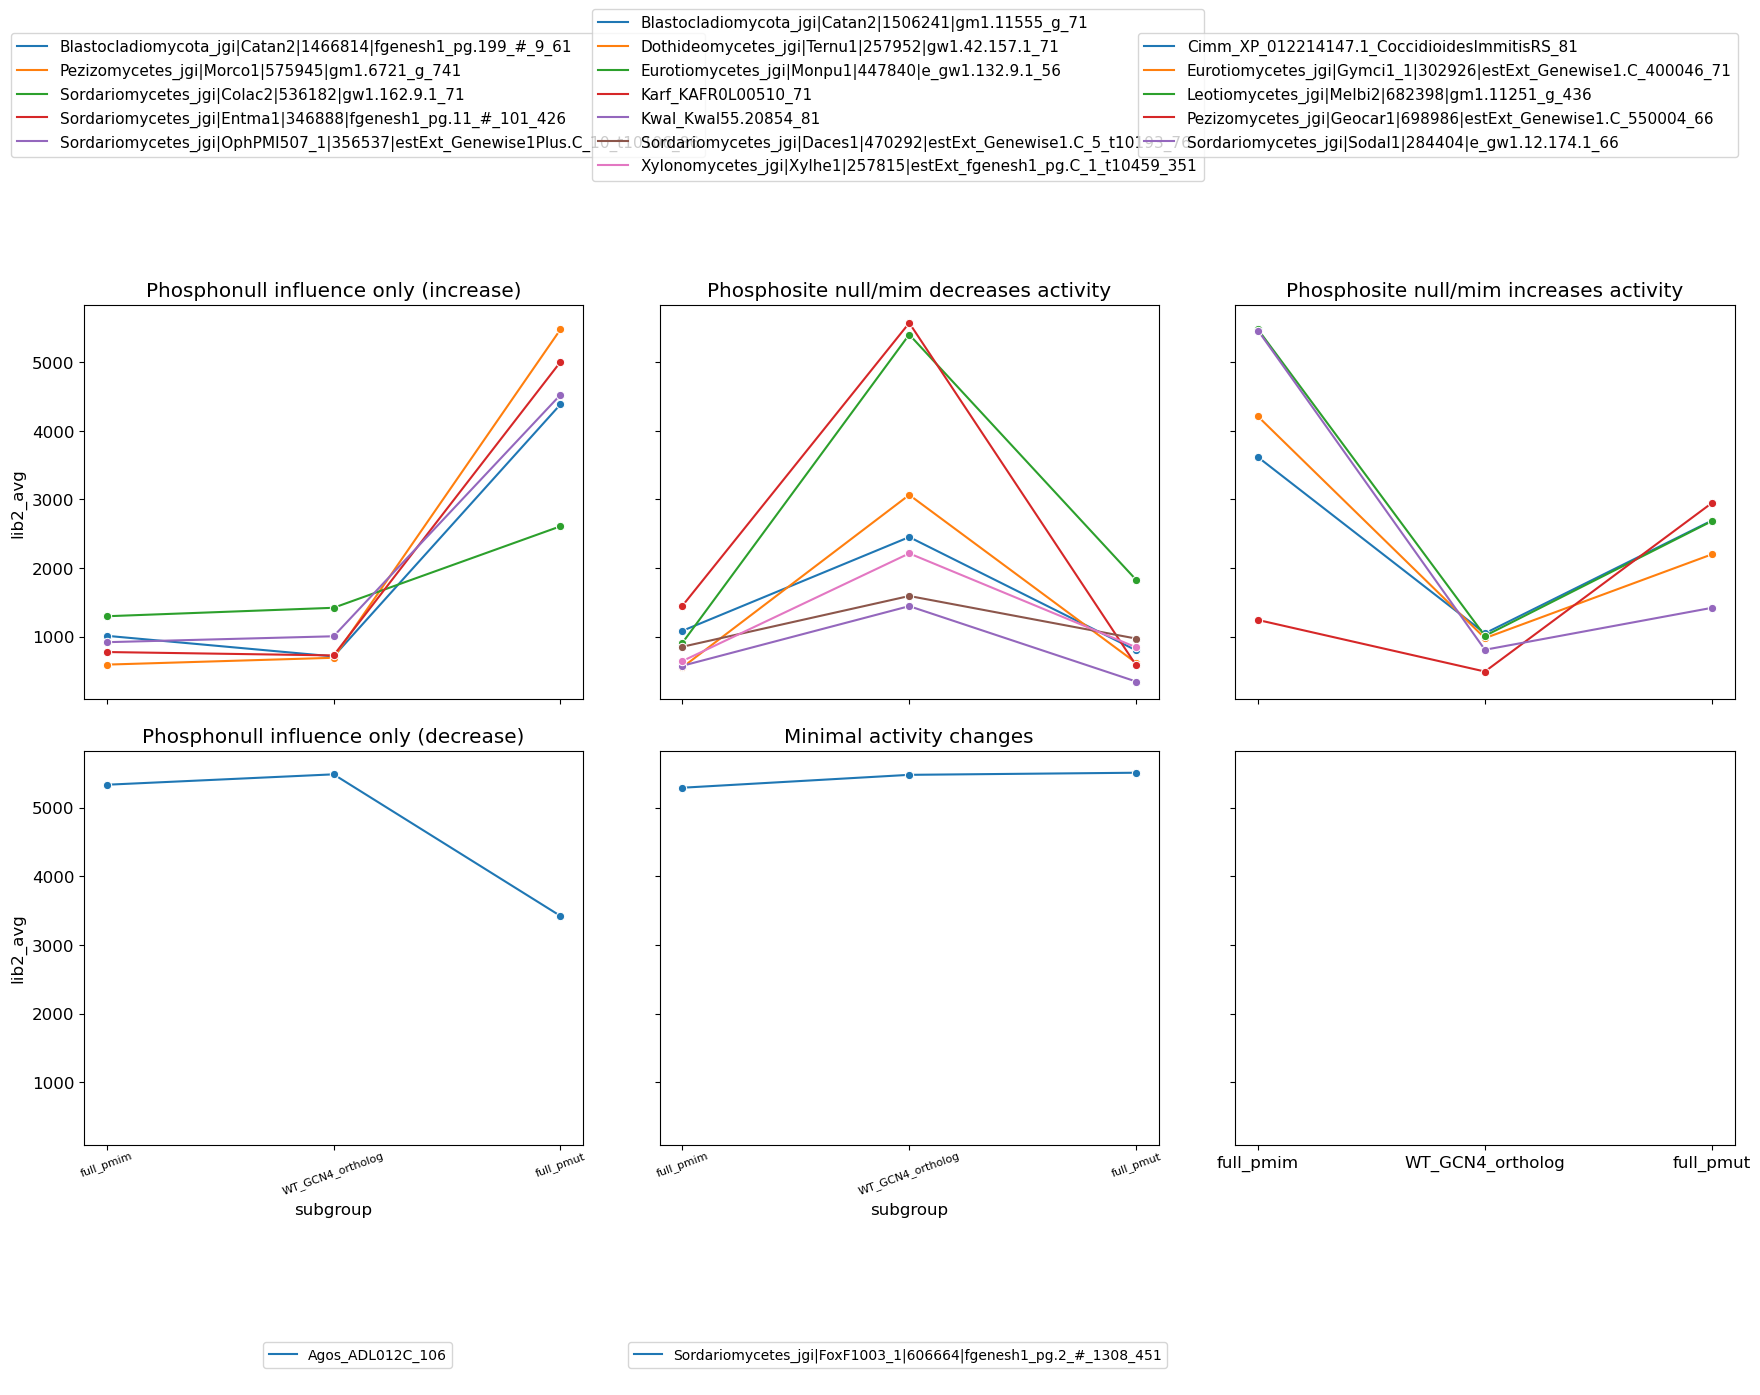

In [57]:
# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12), dpi=100, sharex=True, sharey=True)

# Adjust the layout to prevent overlap
fig.tight_layout(pad=3.0)

# Phosphomutant increases activity (Plot 1)
mimlow_muthigh = gcn4_values_fulmut[(abs(gcn4_values_fulmut['pmim-WT'])<500)&(gcn4_values_fulmut['pmut-WT']>500)]
sns.lineplot(x='subgroup', y='lib2_avg', hue='ortholog_tile_name',
             data=pd.melt(mimlow_muthigh, id_vars='ortholog_tile_name',
                          value_vars=['full_pmim', 'WT_GCN4_ortholog', 'full_pmut'], value_name='lib2_avg'),
             ax=axes[0, 0],
            marker='o',  # Add circular markers (you can change this to 's' for squares)
            markersize=6)
axes[0, 0].tick_params('x', labelsize=8, bottom=True, labelrotation=20, pad=0)
axes[0, 0].set_title('Phosphonull influence only (increase)')

# Phosphomutant and mimetic decrease activity (Plot 2)
WThigh_plow = gcn4_values_fulmut[(gcn4_values_fulmut['pmim-WT']<-500)&(gcn4_values_fulmut['pmut-WT']<-500)]
sns.lineplot(x='subgroup', y='lib2_avg', hue='ortholog_tile_name',
             data=pd.melt(WThigh_plow, id_vars='ortholog_tile_name',
                          value_vars=['full_pmim', 'WT_GCN4_ortholog', 'full_pmut'], value_name='lib2_avg'),
             ax=axes[0, 1],
            marker='o',  # Add circular markers (you can change this to 's' for squares)
            markersize=6)
axes[0, 1].tick_params('x', labelsize=8, bottom=True, labelrotation=20, pad=0)
axes[0, 1].set_title('Phosphosite null/mim decreases activity')

#Phosphomutant and mimetic increase activity (Plot 3)
WTlow_phigh = gcn4_values_fulmut[(gcn4_values_fulmut['pmim-WT']>500)&(gcn4_values_fulmut['pmut-WT']>500)]
sns.lineplot(x='subgroup', y='lib2_avg', hue='ortholog_tile_name',
             data=pd.melt(WTlow_phigh, id_vars='ortholog_tile_name',
                          value_vars=['full_pmim', 'WT_GCN4_ortholog', 'full_pmut'], value_name='lib2_avg'),
             ax=axes[0, 2],
            marker='o',  # Add circular markers (you can change this to 's' for squares)
            markersize=6)
axes[0, 2].tick_params('x', labelsize=8, bottom=True, labelrotation=20, pad=0)
axes[0, 2].set_title('Phosphosite null/mim increases activity')

# Phosphomutant decreases activity (Plot 4)
pmutlow = gcn4_values_fulmut[(abs(gcn4_values_fulmut['pmim-WT'])<500)&((gcn4_values_fulmut['pmut-WT'])<-500)]
sns.lineplot(x='subgroup', y='lib2_avg', hue='ortholog_tile_name',
             data=pd.melt(pmutlow, id_vars='ortholog_tile_name',
                          value_vars=['full_pmim', 'WT_GCN4_ortholog', 'full_pmut'], value_name='lib2_avg'),
             ax=axes[1, 0],
            marker='o',  # Add circular markers (you can change this to 's' for squares)
            markersize=6)
axes[1, 0].tick_params('x', labelsize=8, bottom=True, labelrotation=20, pad=0)
axes[1, 0].set_title('Phosphonull influence only (decrease)')

# # Phosphomimetic has lowest activity (Plot 5)
# pmimlow = gcn4_values_fulmut[(gcn4_values_fulmut['pmim-WT']<-500)&(abs(gcn4_values_fulmut['pmut-WT'])<500)]
# sns.lineplot(x='subgroup', y='lib2_avg', hue='ortholog_tile_name',
#              data=pd.melt(pmimlow, id_vars='ortholog_tile_name',
#                           value_vars=['full_pmim', 'WT_GCN4_ortholog', 'full_pmut'], value_name='lib2_avg'),
#              ax=axes[1, 1])
# axes[1, 1].tick_params('x', labelsize=8, bottom=True, labelrotation=20, pad=0)
# axes[1, 1].set_title('Phosphomimetic has lowest activity')

# Minimal changes (Plot 5)
nochange = gcn4_values_fulmut[(abs(gcn4_values_fulmut['pmim-WT'])<500)&(abs(gcn4_values_fulmut['pmut-WT'])<500)]
sns.lineplot(x='subgroup', y='lib2_avg', hue='ortholog_tile_name',
             data=pd.melt(nochange, id_vars='ortholog_tile_name',
                          value_vars=['full_pmim', 'WT_GCN4_ortholog', 'full_pmut'], value_name='lib2_avg'),
             ax=axes[1, 1],
            marker='o',  # Add circular markers (you can change this to 's' for squares)
            markersize=6)
axes[1, 1].tick_params('x', labelsize=8, bottom=True, labelrotation=20, pad=0)
axes[1, 1].set_title('Minimal activity changes') 

# Remove legends from the subplots
for ax in axes.flat:
    try:
        ax.get_legend().remove()
    except:
        pass
# Extract handles and labels for each subplot
handles_labels = [ax.get_legend_handles_labels() for ax in axes.flat]

# Create separate axes for legends and place them above the top row and below the bottom row
# Legend for the top row
for i in range(3):
    legend_ax_top = fig.add_axes([0.1 + i * 0.3, 0.95, 0.2, 0.05])  # Custom position for each legend
    legend_ax_top.axis('off')  # Turn off the axis
    legend_ax_top.legend(*handles_labels[i], loc='center', fontsize=11)

# Legend for the bottom row
for i in range(2):
    legend_ax_bottom = fig.add_axes([0.1 + i * 0.3, -0.1, 0.2, 0.05])  # Custom position for each legend
    legend_ax_bottom.axis('off')  # Turn off the axis
    legend_ax_bottom.legend(*handles_labels[i + 3], loc='center', fontsize=10)

# Adjust layout for better spacing
plt.subplots_adjust(top=0.8, bottom=0.1, 
                    # left = 0.15, right = 0.85
                   )


plt.savefig('fullphosphositedynamics_20241126.svg')

/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: Fu

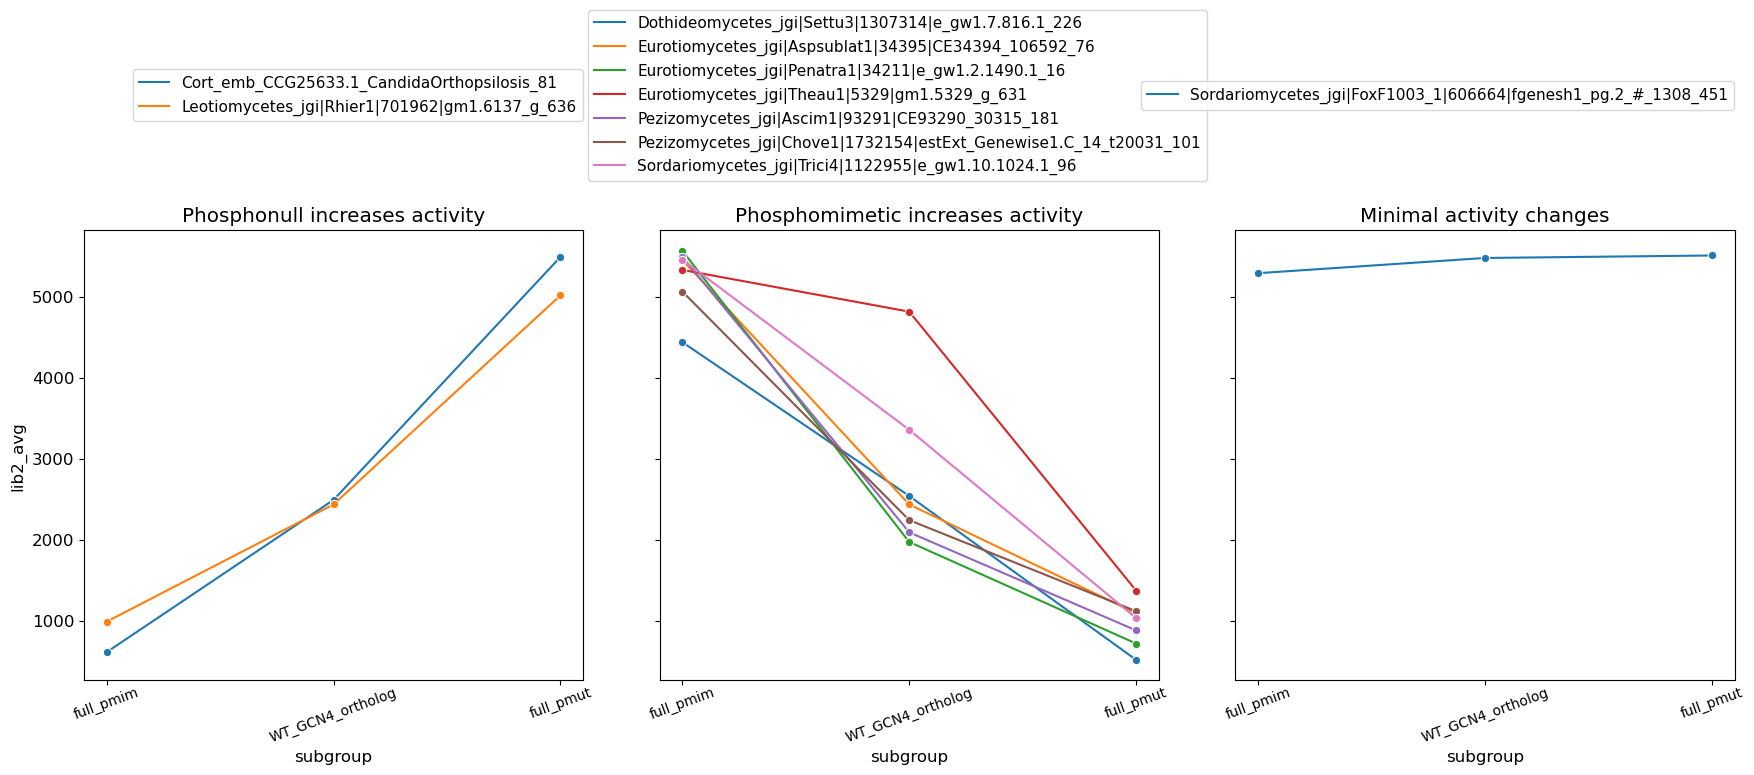

In [58]:
# Create a 2x3 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=100, sharex=True, sharey=True)

# Adjust the layout to prevent overlap
fig.tight_layout(pad=3.0)

# Phosphomutant increases activity, Phosphomimetic decreases (Plot 1)
mut_increase = gcn4_values_fulmut[(gcn4_values_fulmut['pmim-WT']<-500)&(gcn4_values_fulmut['pmut-WT']>500)]
sns.lineplot(x='subgroup', y='lib2_avg', hue='ortholog_tile_name',
             data=pd.melt(mut_increase, id_vars='ortholog_tile_name',
                          value_vars=['full_pmim', 'WT_GCN4_ortholog', 'full_pmut'], value_name='lib2_avg'),
             ax=axes[0],
            marker='o',  # Add circular markers (you can change this to 's' for squares)
            markersize=6)
axes[0].tick_params('x', labelsize=10, bottom=True, labelrotation=20, pad=0)
axes[0].set_title('Phosphonull increases activity')

# Phosphomimetic increases activity,  Phosphomutant decreases (Plot 2)
mim_increase = gcn4_values_fulmut[(gcn4_values_fulmut['pmim-WT']>500)&(gcn4_values_fulmut['pmut-WT']<-500)]
sns.lineplot(x='subgroup', y='lib2_avg', hue='ortholog_tile_name',
             data=pd.melt(mim_increase, id_vars='ortholog_tile_name',
                          value_vars=['full_pmim', 'WT_GCN4_ortholog', 'full_pmut'], value_name='lib2_avg'),
             ax=axes[1],
            marker='o',  # Add circular markers (you can change this to 's' for squares)
            markersize=6)
axes[1].tick_params('x', labelsize=10, bottom=True, labelrotation=20, pad=0)
axes[1].set_title('Phosphomimetic increases activity')

# Minimal changes (Plot 6)
nochange = gcn4_values_fulmut[(abs(gcn4_values_fulmut['pmim-WT'])<500)&(abs(gcn4_values_fulmut['pmut-WT'])<500)]
sns.lineplot(x='subgroup', y='lib2_avg', hue='ortholog_tile_name',
             data=pd.melt(nochange, id_vars='ortholog_tile_name',
                          value_vars=['full_pmim', 'WT_GCN4_ortholog', 'full_pmut'], value_name='lib2_avg'),
             ax=axes[2],
            marker='o',  # Add circular markers (you can change this to 's' for squares)
            markersize=6)
axes[2].tick_params('x', labelsize=10, bottom=True, labelrotation=20, pad=0)
axes[2].set_title('Minimal activity changes')


# Remove legends from the subplots
for ax in axes.flat:
    ax.get_legend().remove()
    
# Extract handles and labels for each subplot
handles_labels = [ax.get_legend_handles_labels() for ax in axes.flat]

# Create separate axes for legends and place them above the top row and below the bottom row
# Legend for the top row
for i in range(3):
    legend_ax_top = fig.add_axes([0.1 + i * 0.3, 0.95, 0.2, 0.05])  # Custom position for each legend
    legend_ax_top.axis('off')  # Turn off the axis
    legend_ax_top.legend(*handles_labels[i], loc='center', fontsize=11)

# Adjust layout for better spacing
plt.subplots_adjust(top=0.75, bottom=0.0, 
                    # left = 0.15, right = 0.85
                   )
plt.savefig('fullphosphositedynamics_small.svg')

In [209]:
# gcn4_values_fulmut.to_csv('fullphosphositedynamics.csv')

In [223]:
gcn4_values_fulmut.head()

subgroup,full_pmim,WT_GCN4_ortholog,full_pmut,ortholog_tile_name,pmim-WT,pmut-WT
0,5333.885501,5485.522907,3421.959793,Agos_ADL012C_106,-151.637406,-2063.563114
1,1012.699035,712.155074,4384.591121,Blastocladiomycota_jgi|Catan2|1466814|fgenesh1...,300.543962,3672.436047
2,1084.830883,2451.305221,800.706411,Blastocladiomycota_jgi|Catan2|1506241|gm1.1155...,-1366.474339,-1650.598810
3,3615.131855,1048.825426,2691.868560,Cimm_XP_012214147.1_CoccidioidesImmitisRS_81,2566.306429,1643.043134
5,616.484692,2494.628446,5491.348064,Cort_emb_CCG25633.1_CandidaOrthopsilosis_81,-1878.143754,2996.719618


## Do full phosphosite mutations behave differentfly than single mutation?

In [210]:
gcn4_values_pmut = gcn4_values.copy(deep=True)
gcn4_values_pmut = gcn4_values_pmut.reset_index()
gcn4_values_pmut = gcn4_values_pmut[['WT_GCN4_ortholog','full_pmut','single_pmut_site_1','single_pmut_site_2','single_pmut_site_3','ortholog_tile_name']]
gcn4_values_pmut = gcn4_values_pmut[gcn4_values_pmut['single_pmut_site_1'].notna()]
gcn4_values_pmut['pmut-WT'] = gcn4_values_pmut['full_pmut'] - gcn4_values_pmut['WT_GCN4_ortholog']
gcn4_values_pmut

subgroup,WT_GCN4_ortholog,full_pmut,single_pmut_site_1,single_pmut_site_2,single_pmut_site_3,ortholog_tile_name,pmut-WT
1,712.155074,4384.591121,643.296732,744.275910,823.384431,Blastocladiomycota_jgi|Catan2|1466814|fgenesh1...,3672.436047
2,2451.305221,800.706411,2938.427288,3626.448481,1079.394536,Blastocladiomycota_jgi|Catan2|1506241|gm1.1155...,-1650.598810
3,1048.825426,2691.868560,1050.116899,1725.963931,NaN,Cimm_XP_012214147.1_CoccidioidesImmitisRS_81,1643.043134
7,NaN,5590.853436,3037.144320,NaN,NaN,Dothideomycetes_jgi|Boeex1|343811|estExt_Genew...,NaN
8,1726.675538,NaN,1003.919596,998.749406,NaN,Dothideomycetes_jgi|Denna1|471682|estExt_Genew...,NaN
9,4410.667909,NaN,958.558735,NaN,NaN,Dothideomycetes_jgi|Epini1|466314|gm1.4452_g_221,NaN
10,NaN,1188.958598,933.523419,NaN,NaN,Dothideomycetes_jgi|Ophdi1|310926|estExt_Genew...,NaN
11,2542.444474,521.324174,2542.852353,NaN,NaN,Dothideomycetes_jgi|Settu3|1307314|e_gw1.7.816...,-2021.120299
15,2438.481565,1096.720151,2199.549427,4833.154730,NaN,Eurotiomycetes_jgi|Aspsublat1|34395|CE34394_10...,-1341.761414
17,978.461660,2199.180171,2197.379812,994.057017,NaN,Eurotiomycetes_jgi|Gymci1_1|302926|estExt_Gene...,1220.718511


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_d

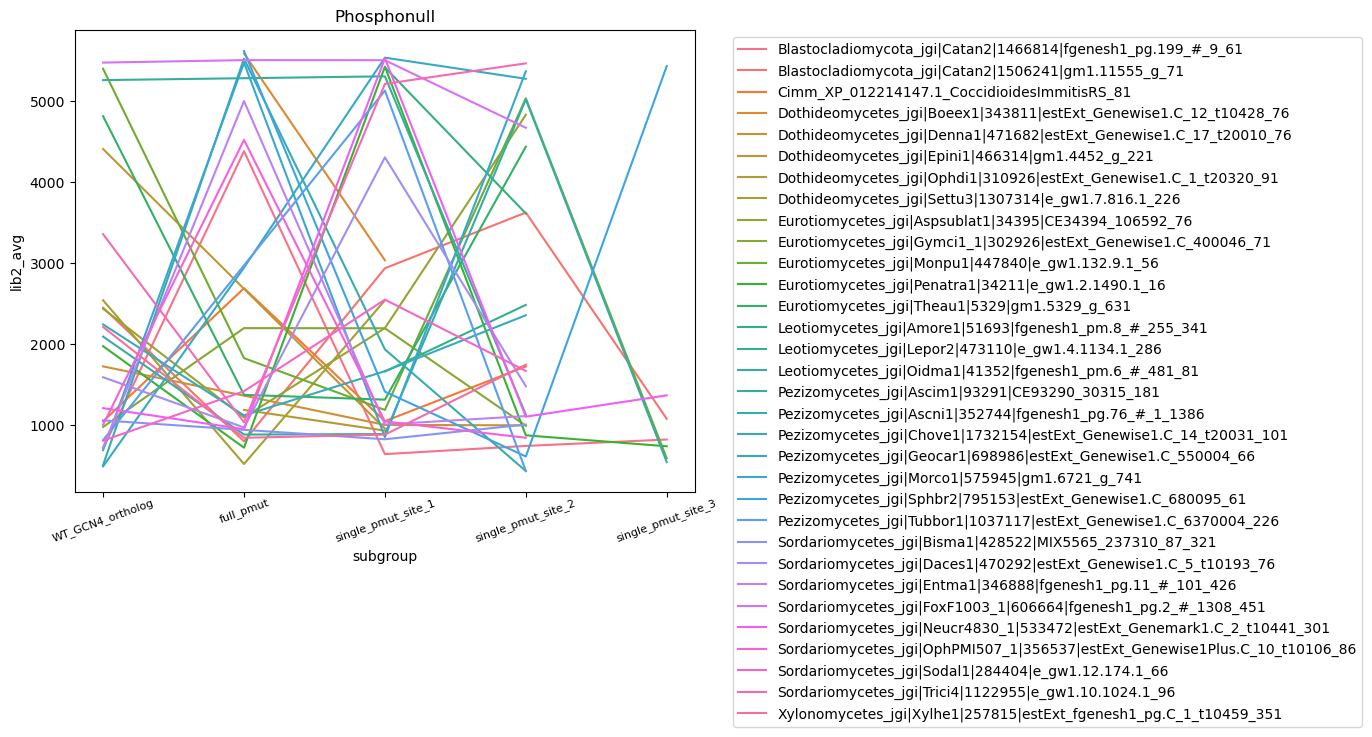

In [211]:

fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', 
             data=pd.melt(gcn4_values_pmut, id_vars='ortholog_tile_name',
                          value_vars=['WT_GCN4_ortholog','full_pmut','single_pmut_site_1','single_pmut_site_2','single_pmut_site_3',], 
                          value_name='lib2_avg'), 
             legend = True)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Phosphonull')
plt.savefig('phosphonulldynamics.svg')

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_d

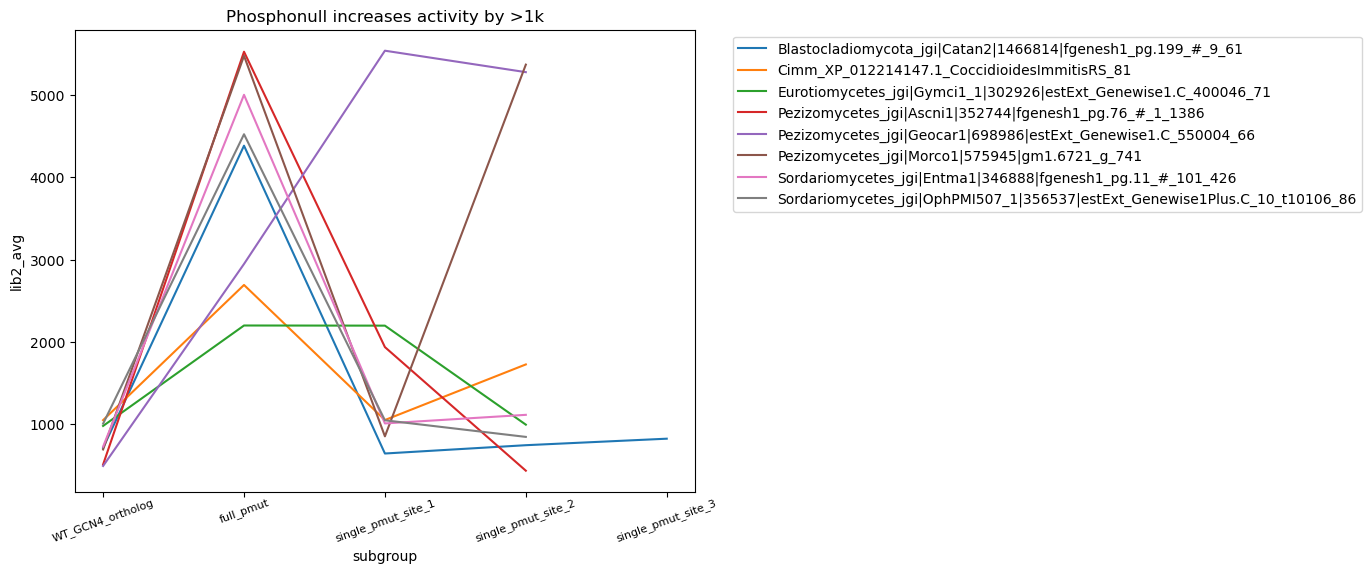

In [212]:
fullpmut_inc = gcn4_values_pmut[gcn4_values_pmut['pmut-WT']>1000]
fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', 
             data=pd.melt(fullpmut_inc, id_vars='ortholog_tile_name',
                          value_vars=['WT_GCN4_ortholog','full_pmut','single_pmut_site_1','single_pmut_site_2','single_pmut_site_3',], 
                          value_name='lib2_avg'), 
             legend = True)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Phosphonull increases activity by >1k')
plt.savefig('phophonull_inc.svg')

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_d

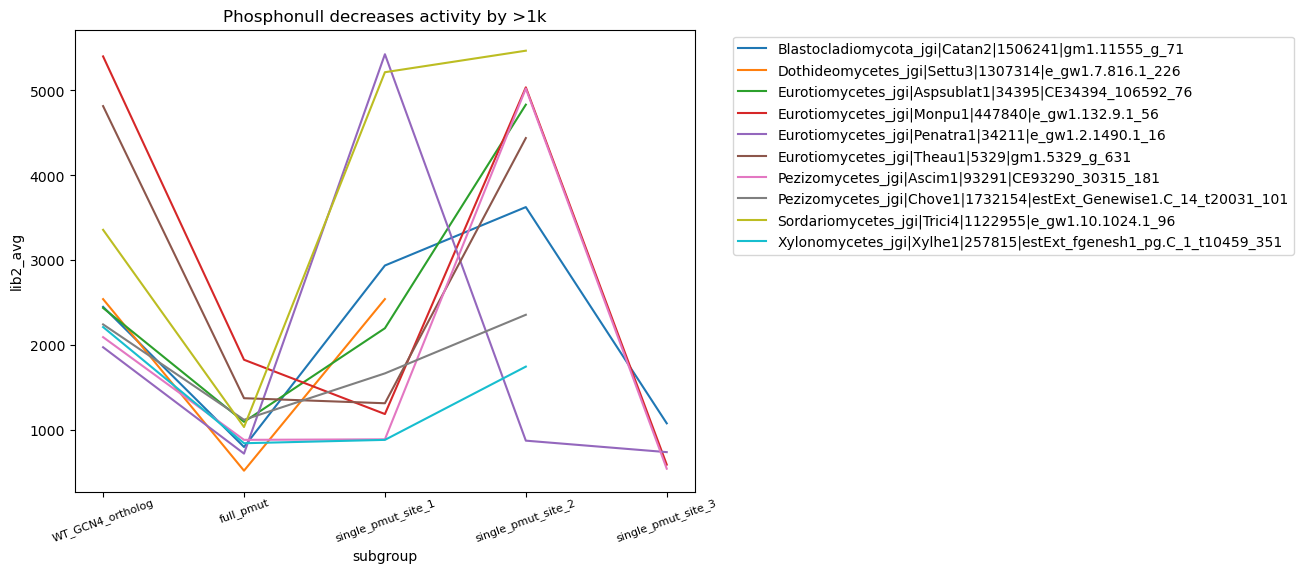

In [213]:
fullpmut_dec = gcn4_values_pmut[gcn4_values_pmut['pmut-WT']<-1000]
fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', 
             data=pd.melt(fullpmut_dec, id_vars='ortholog_tile_name',
                          value_vars=['WT_GCN4_ortholog','full_pmut','single_pmut_site_1','single_pmut_site_2','single_pmut_site_3',], 
                          value_name='lib2_avg'), 
             legend = True)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Phosphonull decreases activity by >1k')
plt.savefig('phophonull_dec.svg')

In [163]:
gcn4_values.head()

subgroup,WT_GCN4_ortholog,full_pmim,full_pmut,single_pmim_site_1,single_pmim_site_2,single_pmim_site_3,single_pmut_site_1,single_pmut_site_2,single_pmut_site_3
ortholog_tile_name,,,,,,,,,
Agos_ADL012C_106,5485.522907,5333.885501,3421.959793,NaN,NaN,NaN,NaN,NaN,NaN
Blastocladiomycota_jgi|Catan2|1466814|fgenesh1_pg.199_#_9_61,712.155074,1012.699035,4384.591121,4403.201555,636.233499,1213.633107,643.296732,744.275910,823.384431
Blastocladiomycota_jgi|Catan2|1506241|gm1.11555_g_71,2451.305221,1084.830883,800.706411,3508.534686,926.196589,727.066450,2938.427288,3626.448481,1079.394536
Cimm_XP_012214147.1_CoccidioidesImmitisRS_81,1048.825426,3615.131855,2691.868560,4534.842819,1235.784532,NaN,1050.116899,1725.963931,NaN
Cmal_EMG49335.1_CandidaMaltosaXu316_76,1523.140618,1144.509777,5521.473299,NaN,NaN,NaN,NaN,NaN,NaN


In [214]:
gcn4_values_pmim = gcn4_values.copy(deep=True)
gcn4_values_pmim = gcn4_values_pmim.reset_index()
gcn4_values_pmim = gcn4_values_pmim[['WT_GCN4_ortholog','full_pmim','single_pmim_site_1','single_pmim_site_2','single_pmim_site_3','ortholog_tile_name']]
gcn4_values_pmim = gcn4_values_pmim[gcn4_values_pmim['single_pmim_site_1'].notna()]
gcn4_values_pmim['pmim-WT'] = gcn4_values_pmim['full_pmim'] - gcn4_values_pmim['WT_GCN4_ortholog']
gcn4_values_pmim

subgroup,WT_GCN4_ortholog,full_pmim,single_pmim_site_1,single_pmim_site_2,single_pmim_site_3,ortholog_tile_name,pmim-WT
1,712.155074,1012.699035,4403.201555,636.233499,1213.633107,Blastocladiomycota_jgi|Catan2|1466814|fgenesh1...,300.543962
2,2451.305221,1084.830883,3508.534686,926.196589,727.066450,Blastocladiomycota_jgi|Catan2|1506241|gm1.1155...,-1366.474339
3,1048.825426,3615.131855,4534.842819,1235.784532,NaN,Cimm_XP_012214147.1_CoccidioidesImmitisRS_81,2566.306429
7,NaN,NaN,5567.579703,NaN,NaN,Dothideomycetes_jgi|Boeex1|343811|estExt_Genew...,NaN
8,1726.675538,845.067820,801.297258,835.212124,NaN,Dothideomycetes_jgi|Denna1|471682|estExt_Genew...,-881.607719
11,2542.444474,4439.520411,521.588086,594.946043,NaN,Dothideomycetes_jgi|Settu3|1307314|e_gw1.7.816...,1897.075938
12,3065.411765,553.345392,915.175446,1513.356521,4293.719386,Dothideomycetes_jgi|Ternu1|257952|gw1.42.157.1_71,-2512.066373
15,2438.481565,5454.822129,872.987173,940.260699,NaN,Eurotiomycetes_jgi|Aspsublat1|34395|CE34394_10...,3016.340564
16,5476.897656,3789.327602,1749.189428,4987.773197,NaN,Eurotiomycetes_jgi|Eurhe1|484251|estExt_Genewi...,-1687.570053
17,978.461660,4207.860345,1385.151291,NaN,NaN,Eurotiomycetes_jgi|Gymci1_1|302926|estExt_Gene...,3229.398685


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_d

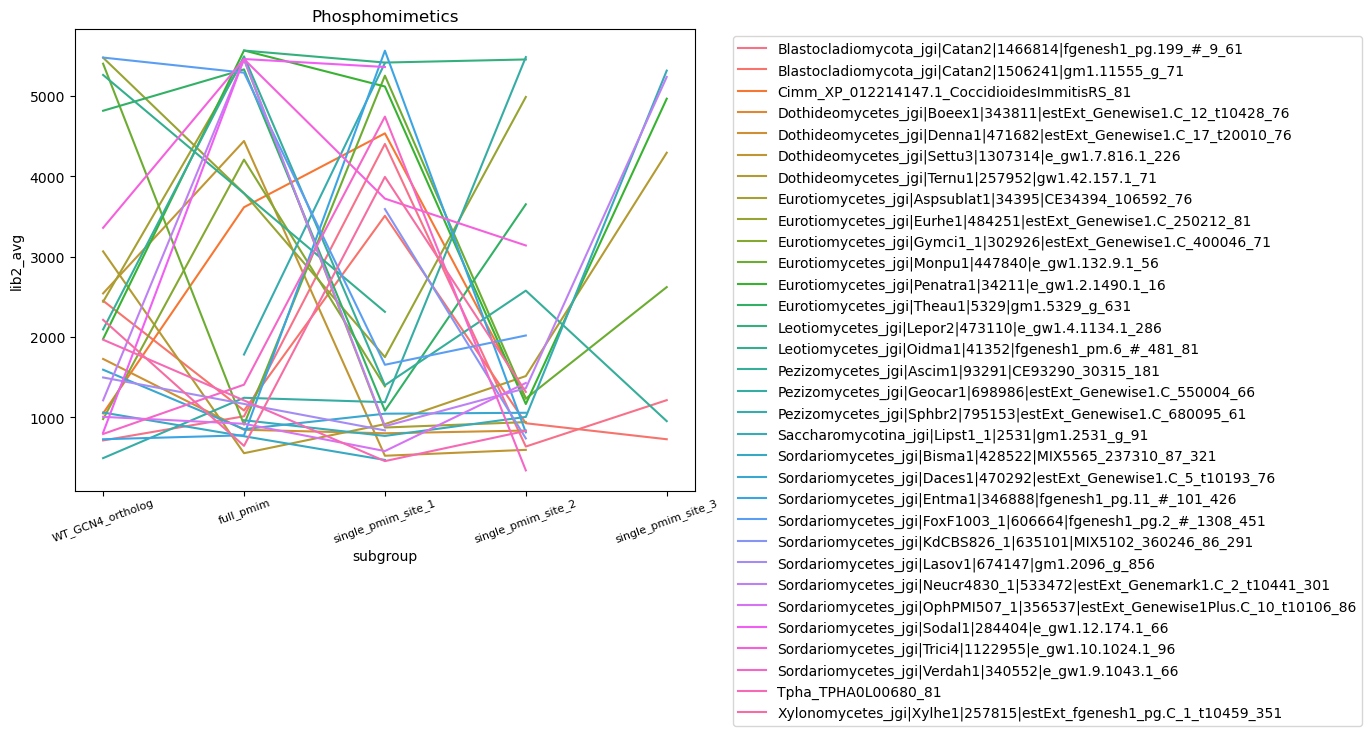

In [215]:

fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', 
             data=pd.melt(gcn4_values_pmim, id_vars='ortholog_tile_name',
                          value_vars=['WT_GCN4_ortholog','full_pmim','single_pmim_site_1','single_pmim_site_2','single_pmim_site_3'], 
                          value_name='lib2_avg'), 
             legend = True)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Phosphomimetics')
plt.savefig('phosphomimeticdynamics.svg')

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_d

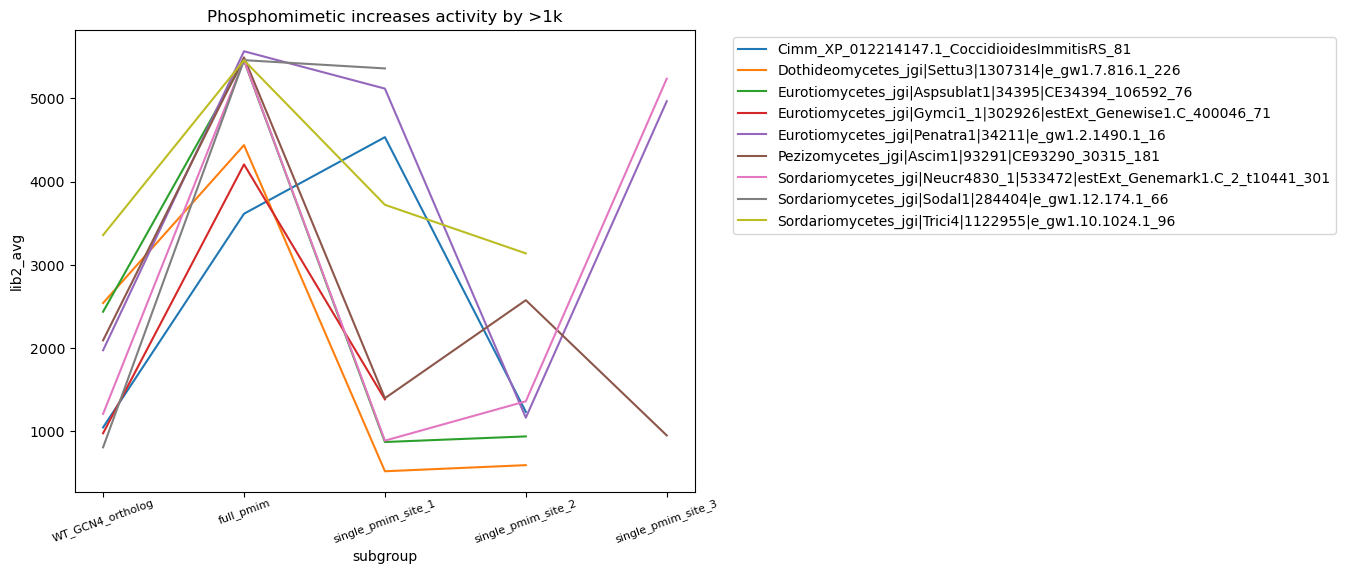

In [216]:
fullpmim_inc = gcn4_values_pmim[gcn4_values_pmim['pmim-WT']>1000]
fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', 
             data=pd.melt(fullpmim_inc, id_vars='ortholog_tile_name',
                          value_vars=['WT_GCN4_ortholog','full_pmim','single_pmim_site_1','single_pmim_site_2','single_pmim_site_3'], 
                          value_name='lib2_avg'), 
             legend = True)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Phosphomimetic increases activity by >1k')
plt.savefig('phosphomimetic_inc.svg')

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_d

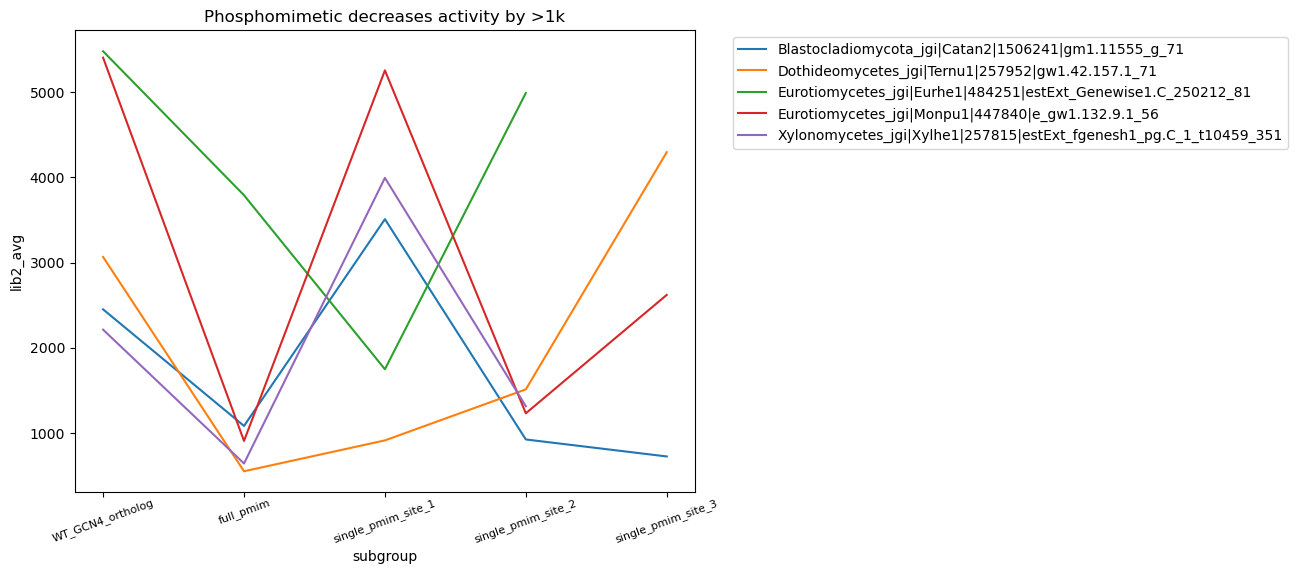

In [217]:
fullpmim_dec = gcn4_values_pmim[gcn4_values_pmim['pmim-WT']<-1000]
fig, axes = plt.subplots(1,1, figsize=(8, 6), dpi = 100)

sns.lineplot(x = 'subgroup', y = 'lib2_avg',hue = 'ortholog_tile_name', 
             data=pd.melt(fullpmim_dec, id_vars='ortholog_tile_name',
                          value_vars=['WT_GCN4_ortholog','full_pmim','single_pmim_site_1','single_pmim_site_2','single_pmim_site_3'], 
                          value_name='lib2_avg'), 
             legend = True)
axes.tick_params('x', labelsize = 8, bottom = True, labelrotation = 20, pad = 0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Phosphomimetic decreases activity by >1k')
plt.savefig('phosphomimetic_dec.svg')

In [218]:
# gcn4_values_pmut.to_csv('phosphonulldynamics.csv')

In [220]:
# gcn4_values_pmim.to_csv('phosphomimeticdynamics.csv')

## Move all of this analysis into a folder to copy to local (to_local/)

First iteration I forgot to impose threshold on gcn4_values --> these files went to oct11_to_local
Second iteration I imposed 100 read per sort threshold --> oct11_to_local_thresh